# Эскалация в СМИ как предиктор агрессии: США — Венесуэла на окне 60 дней

**Данные:** GDELT 1.0 Event Export, события с участием США и Венесуэлы,
окно **01.11.2025 — 02.01.2026** (63 дня по `DATEADDED`), 11 505 строк, 58 колонок.

**День X** — захват Мадуро, 3 января 2026. В данных его нет: окно обрывается 2 января.

**Зачем этот отчёт.** Предыдущий анализ делался на 18 днях (16.12–02.01) и упирался в три
ограничения: праздничный провал медиапотока совпадал с «предвоенным» периодом, базового уровня
не было видно, а мощности не хватало даже на умеренный эффект. 63 дня снимают все три. Поэтому
здесь не просто пересчёт, а **прямое сравнение: что из выводов 18-дневной версии устояло,
а что оказалось артефактом короткого окна.**

Спойлер для нетерпеливых: главный вывод прошлого отчёта — «перед днём X словарь новостей
переключился с экономического принуждения на кинетику» — **не подтвердился**. На 60 днях видно,
что кинетическая лексика была нормой в ноябре, аномалией был декабрьский провал, а «переключение»
29 декабря — возврат к базовому уровню. Зато появился сигнал там, где на 18 днях его не было.

---

### Структура

1. Загрузка и первичная проверка (включая сверку с 18-дневной выгрузкой)
2. EDA
3. Предобработка
4. Метрики дневного агрегата
5. Периоды и скользящие окна
6. Проверка гипотез + поправка Бонферрони + устойчивость
7. Визуализация
8. Что изменилось против 18-дневной версии
9. Выводы

## 0. Настройка окружения

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")

print("Окружение готово. pandas", pd.__version__, "| numpy", np.__version__)

Окружение готово. pandas 3.0.5 | numpy 2.4.6


---
## 1. Загрузка и первичная проверка

In [2]:
CSV_PATH     = "data/usa_venezuela_60d.csv"      # 63 дня: 01.11.2025 — 02.01.2026
CSV_PATH_18D = "data/usa_venezuela_gdelt.csv"    # прежняя выгрузка: 16.12.2025 — 02.01.2026

df = pd.read_csv(CSV_PATH, encoding="utf-8", low_memory=False)
print("Размерность (строк, колонок):", df.shape)

df["date_added"] = pd.to_datetime(df["DATEADDED"].astype(str), format="%Y%m%d")
df["sql_date"]   = pd.to_datetime(df["SQLDATE"].astype(str),   format="%Y%m%d")

full  = pd.date_range(df.date_added.min(), df.date_added.max(), freq="D")
have  = pd.DatetimeIndex(sorted(df.date_added.unique()))
print("DATEADDED:", df.date_added.min().date(), "->", df.date_added.max().date(),
      f"| дней с данными: {len(have)} из {len(full)}")
print("Пропущенные дни:", "нет" if len(full.difference(have)) == 0 else list(full.difference(have).date))
print("SQLDATE:", df.sql_date.min().date(), "->", df.sql_date.max().date())
lag = (df.date_added - df.sql_date).dt.days
print(f"Лаг DATEADDED - SQLDATE: медиана {int(lag.median())} дн., 90-й перцентиль {int(lag.quantile(0.9))} дн.")
print("Дубликатов GLOBALEVENTID:", int(df.GLOBALEVENTID.duplicated().sum()))

Размерность (строк, колонок): (11505, 58)
DATEADDED: 2025-11-01 -> 2026-01-02 | дней с данными: 63 из 63
Пропущенные дни: нет
SQLDATE: 2015-12-14 -> 2026-01-02
Лаг DATEADDED - SQLDATE: медиана 0 дн., 90-й перцентиль 0 дн.
Дубликатов GLOBALEVENTID: 0


In [3]:
# --- Сверка с прежней 18-дневной выгрузкой: это должен быть строгий надмножественный набор ---
df18 = pd.read_csv(CSV_PATH_18D, encoding="utf-8", low_memory=False)
overlap_window = df[df.date_added >= pd.Timestamp("2025-12-16")]

print("Строк в 18-дневной выгрузке:", len(df18))
print("Строк в том же окне внутри 60-дневной:", len(overlap_window))
print("Совпадение по GLOBALEVENTID:", len(set(overlap_window.GLOBALEVENTID) & set(df18.GLOBALEVENTID)),
      "из", len(df18))
print("\nНовых дней добавилось:", df.date_added.nunique() - df18.DATEADDED.nunique(),
      "| новых строк:", len(df) - len(df18))

Строк в 18-дневной выгрузке: 3742
Строк в том же окне внутри 60-дневной: 3742
Совпадение по GLOBALEVENTID: 3742 из 3742

Новых дней добавилось: 45 | новых строк: 7763


**Вывод по разделу 1.** 11 505 событий за 63 календарных дня, **ни одного пропущенного дня**.
Прежняя 18-дневная выгрузка входит в новую точь-в-точь: все 3 742 строки совпадают по
`GLOBALEVENTID`. Значит, любое расхождение выводов дальше — это следствие **более длинного окна**,
а не другого способа сбора данных. Добавилось 45 дней и 7 763 строки: ноябрь и первая половина
декабря, которых мы раньше не видели.

---
## 2. EDA — разведочный анализ

### 2.1 Пропуски по колонкам

In [4]:
na = pd.DataFrame({"n_missing": df.isna().sum(),
                   "pct_missing": (df.isna().mean() * 100).round(1)}).sort_values("n_missing", ascending=False)
display(na[na.n_missing > 0])
print("Колонок без пропусков:", int((na.n_missing == 0).sum()), "из", df.shape[1])
print("\nКлючевые колонки анализа:")
for c in ["DATEADDED", "GoldsteinScale", "AvgTone", "NumArticles", "EventRootCode", "EventCode",
          "QuadClass", "IsRootEvent", "ActionGeo_CountryCode", "ActionGeo_Lat", "SOURCEURL"]:
    print(f"  {c:<22} пропусков: {int(df[c].isna().sum())}")

,n_missing,pct_missing
Actor1KnownGroupCode,11505,100.0000
Actor1EthnicCode,11505,100.0000
Actor1Religion1Code,11505,100.0000
Actor1Religion2Code,11505,100.0000
Actor2Religion1Code,11505,100.0000
Actor2KnownGroupCode,11505,100.0000
Actor2EthnicCode,11505,100.0000
Actor2Religion2Code,11505,100.0000
Actor1Type3Code,11505,100.0000
Actor2Type3Code,11504,100.0000


Колонок без пропусков: 46 из 60

Ключевые колонки анализа:
  DATEADDED              пропусков: 0
  GoldsteinScale         пропусков: 0
  AvgTone                пропусков: 0
  NumArticles            пропусков: 0
  EventRootCode          пропусков: 0
  EventCode              пропусков: 0
  QuadClass              пропусков: 0
  IsRootEvent            пропусков: 0
  ActionGeo_CountryCode  пропусков: 0
  ActionGeo_Lat          пропусков: 0
  SOURCEURL              пропусков: 0


### 2.2 Поток событий по дням: теперь виден базовый уровень

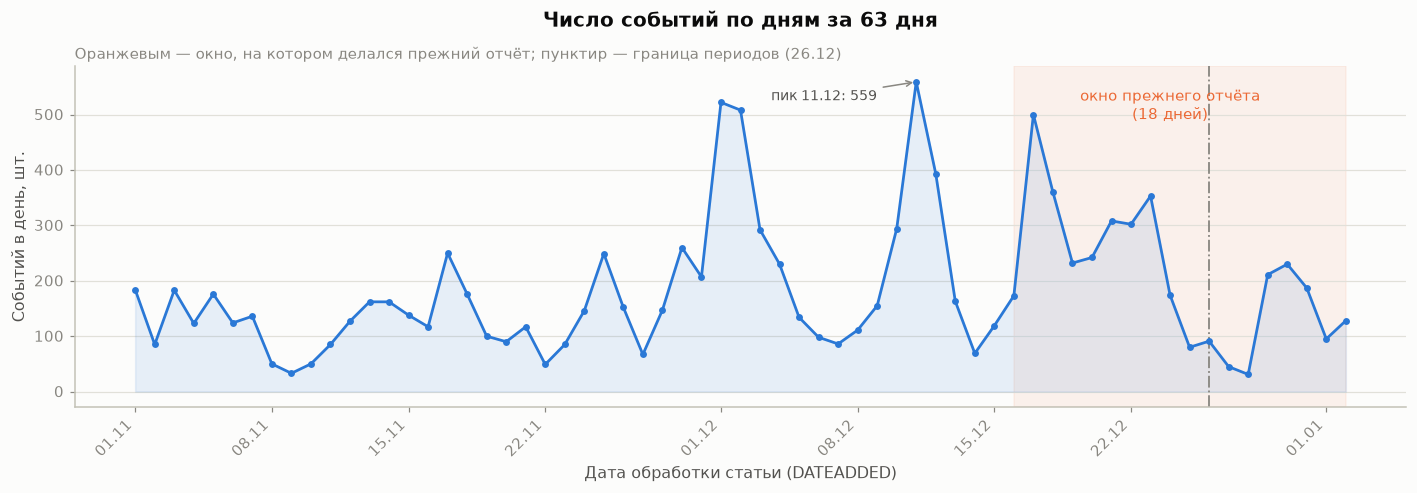

Событий в день — медиана: 152 | мин: 31 | макс: 559
Ноябрь:  медиана 131
Декабрь: медиана 211
Последние 7 дней (27.12–02.01): медиана 128


In [5]:
by_day = df.groupby("date_added").size().rename("events")
W18 = pd.Timestamp("2025-12-16")     # начало прежнего 18-дневного окна
SPLIT = pd.Timestamp("2025-12-26")   # граница периодов (как в прежнем отчёте)

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(by_day.index, by_day.values, color=BLUE, lw=1.8, marker="o", markersize=3.5, zorder=3)
ax.fill_between(by_day.index, by_day.values, color=BLUE, alpha=0.10, zorder=2)
ax.axvspan(W18, by_day.index.max(), color=ORANGE, alpha=0.08, zorder=1)
ax.axvline(SPLIT, color=MUTED, lw=1.2, ls="-.")
ax.annotate("окно прежнего отчёта\n(18 дней)", xy=(pd.Timestamp("2025-12-24"), by_day.max() * 0.88),
            color=ORANGE, fontsize=9.5, ha="center")
ax.annotate(f"пик 11.12: {by_day.max()}", xy=(pd.Timestamp("2025-12-11"), by_day.max()),
            xytext=(-95, -12), textcoords="offset points", color=INK_2, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.set_title("Число событий по дням за 63 дня")
subtitle(ax, "Оранжевым — окно, на котором делался прежний отчёт; пунктир — граница периодов (26.12)")
ax.set_xlabel("Дата обработки статьи (DATEADDED)"); ax.set_ylabel("Событий в день, шт.")
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

print("Событий в день — медиана:", int(by_day.median()), "| мин:", int(by_day.min()),
      "| макс:", int(by_day.max()))
print("Ноябрь:  медиана", int(by_day[:"2025-11-30"].median()))
print("Декабрь: медиана", int(by_day["2025-12-01":"2025-12-31"].median()))
print("Последние 7 дней (27.12–02.01): медиана", int(by_day["2025-12-27":].median()))

**Вывод.** Главное, что даёт длинное окно, — **базовый уровень**. Видно, что декабрь вообще
шумнее ноября (медиана 211 против 131 события в день), что настоящий пик медиапотока пришёлся
на 1–2 и 10–12 декабря (500–559 событий), а вовсе не на последнюю неделю, и что последние семь
дней перед днём X (медиана 128) — это **обычный, даже пониженный** уровень. На 18-дневном окне
этого не было видно вообще: там 17 декабря выглядело пиком, потому что раньше данных не было.

### 2.3 Распределения и проверка нормальности

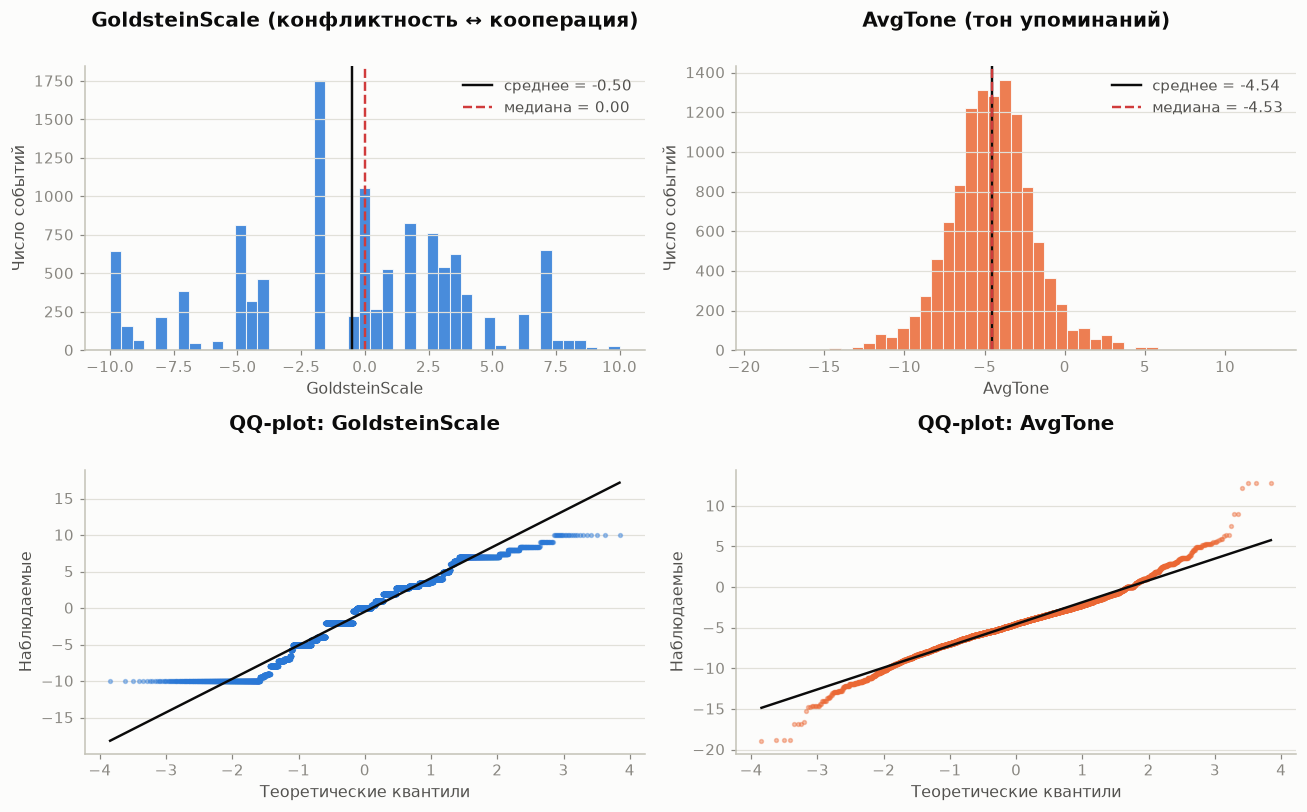

Тест Шапиро-Уилка (H0: выборка нормальна):
  GoldsteinScale  W = 0.9670  p = 4.819e-45  -> НЕ нормально  | асимметрия -0.30, эксцесс -0.56
  AvgTone         W = 0.9830  p = 8.832e-35  -> НЕ нормально  | асимметрия +0.09, эксцесс +1.96


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for j, (col, color, title) in enumerate([
        ("GoldsteinScale", BLUE,   "GoldsteinScale (конфликтность ↔ кооперация)"),
        ("AvgTone",        ORANGE, "AvgTone (тон упоминаний)")]):
    x = df[col].dropna()
    ax = axes[0, j]
    ax.hist(x, bins=45, color=color, alpha=0.85, edgecolor=SURFACE, linewidth=0.7)
    ax.axvline(x.mean(), color=INK, lw=1.6, label=f"среднее = {x.mean():.2f}")
    ax.axvline(x.median(), color=CRITICAL, lw=1.6, ls="--", label=f"медиана = {x.median():.2f}")
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("Число событий"); ax.legend()
    ax = axes[1, j]
    stats.probplot(x, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=2.5, color=color, alpha=0.4, linestyle="none")
    ax.get_lines()[1].set(color=INK, linewidth=1.6)
    ax.set_title(f"QQ-plot: {col}"); ax.set_xlabel("Теоретические квантили"); ax.set_ylabel("Наблюдаемые")
plt.tight_layout(); plt.show()

print("Тест Шапиро-Уилка (H0: выборка нормальна):")
for col in ["GoldsteinScale", "AvgTone"]:
    x = df[col].dropna()
    W, p = stats.shapiro(x)
    print(f"  {col:<15} W = {W:.4f}  p = {p:.3e}  -> "
          f"{'НЕ нормально' if p < 0.05 else 'нормальность не отвергается'}"
          f"  | асимметрия {stats.skew(x):+.2f}, эксцесс {stats.kurtosis(x):+.2f}")

**Вывод.** Как и на 18 днях, обе переменные нормальность не проходят (p ≈ 10⁻⁷⁰ и ниже — на
выборке в 11 505 наблюдений тест улавливает любое отклонение). `GoldsteinScale` остаётся
дискретным справочником значений, `AvgTone` — с тяжёлыми хвостами. → **Основной тест для
гипотезы A снова Манна-Уитни**, t-тест Уэлча приводится параллельно.

### 2.4 Дни, раздутые одной статьёй

In [7]:
vol = df.groupby("date_added").agg(rows=("GLOBALEVENTID", "size"), unique_urls=("SOURCEURL", "nunique"))
vol["rows_per_url"] = vol.rows / vol.unique_urls
dom = df.groupby("date_added")["SOURCEURL"].agg(
    top_rows=lambda s: s.value_counts().iloc[0], top_url=lambda s: s.value_counts().index[0])
vol = vol.join(dom); vol["top_share_pct"] = (vol.top_rows / vol.rows * 100).round(1)

THRESH = 10.0
distorted = vol[vol.top_share_pct >= THRESH]
print(f"ДНИ, ГДЕ ОДНА СТАТЬЯ ДАЛА >= {THRESH:.0f} % СТРОК ДНЯ ({len(distorted)} из {len(vol)}):")
for d, r in distorted.iterrows():
    mark = "  <- поздний период" if d >= SPLIT else ""
    print(f"  {d.date()}  {int(r.top_rows):>3} из {int(r.rows):>3} строк ({r.top_share_pct:>4} %){mark}")
    print(f"      {r.top_url[:105]}")
DISTORTED_DAYS = list(distorted.index)
print("\nВ среднем строк на статью:", round(vol.rows.sum() / vol.unique_urls.sum(), 2))

ДНИ, ГДЕ ОДНА СТАТЬЯ ДАЛА >= 10 % СТРОК ДНЯ (16 из 63):
  2025-11-02    9 из  85 строк (10.6 %)
      https://www.bbc.com/news/articles/cn401vzjx48o
  2025-11-04   13 из 123 строк (10.6 %)
      https://foreignpolicy.com/2025/11/03/military-buildup-venezuela-u-s-eyes-cuba-trump-maduro/
  2025-11-05   27 из 176 строк (15.3 %)
      https://www.firstpost.com/opinion/venezuela-oil-nicolas-maduro-donald-trump-drug-boats-13948042.html
  2025-11-06   13 из 124 строк (10.5 %)
      https://foreignpolicy.com/2025/11/03/military-buildup-venezuela-us-cuba-trump-maduro/?tpcc=recirc_trendin
  2025-11-08    9 из  50 строк (18.0 %)
      https://www.dailymail.co.uk/news/article-15258707/bin-laden-secret-plan-Venezuela-maduro-trump.html
  2025-11-09    8 из  33 строк (24.2 %)
      https://trinidadexpress.com/special-report/mystery-flights-us-drones-spotted-over-t-t/article_da44aa3c-a5
  2025-11-10    6 из  50 строк (12.0 %)
      https://www.csmonitor.com/USA/Justice/2025/1110/drug-boat-strike-venez

### 2.5 Топ-10 SOURCEURL и выбросы

In [8]:
top10 = df.SOURCEURL.value_counts().head(10).rename("rows").to_frame()
top10["day"] = [df.loc[df.SOURCEURL == u, "date_added"].min().date() for u in top10.index]
top10["url_short"] = [u[:92] + ("…" if len(u) > 92 else "") for u in top10.index]
display(top10.reset_index(drop=True)[["url_short", "rows", "day"]])

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr
for col in ["GoldsteinScale", "AvgTone"]:
    s = df[col].dropna(); lo, hi = iqr_bounds(s)
    out = s[(s < lo) | (s > hi)]
    print(f"{col}: границы IQR [{lo:.2f}; {hi:.2f}] -> выбросов {len(out)} ({len(out)/len(s)*100:.1f} %)")

,url_short,rows,day
0,https://www.firstpost.com/opinion/venezuela-oi...,27,2025-11-05
1,https://www.irishtimes.com/world/americas/2025...,18,2025-11-30
2,https://www.gulfcoastnewsnow.com/article/white...,18,2025-12-02
3,https://www.cnn.com/2025/12/01/americas/venezu...,18,2025-12-02
4,https://abc17news.com/news/national-world/cnn-...,17,2025-12-02
5,https://www.cpr.org/2025/12/03/venezuelans-imm...,17,2025-12-03
6,https://www.aol.co.uk/articles/trump-could-top...,16,2025-11-13
7,https://grenadachronicle.com/trump-aide-stephe...,16,2025-12-18
8,https://www.stabroeknews.com/2025/11/16/news/r...,15,2025-11-17
9,https://human-wrongs-watch.net/2025/11/21/nobe...,15,2025-11-21


GoldsteinScale: границы IQR [-14.50; 13.50] -> выбросов 0 (0.0 %)
AvgTone: границы IQR [-10.73; 1.69] -> выбросов 413 (3.6 %)


**Вывод по разделу 2.** Структура данных та же, что и на коротком окне: одна статья даёт в
среднем 2,74 строки-события, выбросов по `GoldsteinScale` нет (шкала ограничена диапазоном),
по `AvgTone` их около 2 % и они содержательны. Дней, где одна статья дала 10 % и больше строк,
стало больше — но в процентном отношении их доля та же, и это по-прежнему в основном дни с
маленьким знаменателем (выходные, праздники).

---
## 3. Предобработка и 4. Метрики

Логика полностью совпадает с 18-дневным отчётом, чтобы результаты были сравнимы: строки не
удаляются, пропуски в типах акторов трактуются как «тип не размечен», объём статей считается
после дедупликации по `SOURCEURL`, метрики те же самые — включая три узкие
(`force_use_share`, `caribbean_concentration_share`, `kinetic_vs_coercion_ratio`).

In [9]:
# --- Пропуски: явный отчёт, строки не удаляем ---
df["Actor1Type1Code"] = df["Actor1Type1Code"].fillna("")
df["Actor2Type1Code"] = df["Actor2Type1Code"].fillna("")
print("Строк до обработки:", len(df), "| после:", len(df), "(удалено 0)")
print("Уникальных статей:", df.SOURCEURL.nunique(),
      f"| строк на статью: {len(df)/df.SOURCEURL.nunique():.2f}")

# --- Признаки уровня события ---
df["is_conflict_hard"] = df.EventRootCode.isin([18, 19, 20]).astype(int)
df["is_material_conf"] = (df.QuadClass == 4).astype(int)
df["is_mil_actor"]     = ((df.Actor1Type1Code == "MIL") | (df.Actor2Type1Code == "MIL")).astype(int)
df["is_root_event"]    = (df.IsRootEvent == 1).astype(int)
df["neg_intensity"]    = np.where(df.GoldsteinScale < 0, df.NumArticles * df.GoldsteinScale, 0.0)
df["is_force_use"]     = df.EventCode.isin([190, 193, 195]).astype(int)
df["is_caribbean"]     = (df.ActionGeo_Lat.between(8, 23) & df.ActionGeo_Long.between(-87, -59)).astype(int)
print("\nДоли по всей выборке: жёсткий конфликт", f"{df.is_conflict_hard.mean():.3f}",
      "| материальный", f"{df.is_material_conf.mean():.3f}",
      "| применение силы", f"{df.is_force_use.mean():.3f}",
      "| Карибы", f"{df.is_caribbean.mean():.3f}")

Строк до обработки: 11505 | после: 11505 (удалено 0)
Уникальных статей: 4202 | строк на статью: 2.74

Доли по всей выборке: жёсткий конфликт 0.069 | материальный 0.166 | применение силы 0.053 | Карибы 0.551


In [10]:
# --- Словарь слагов URL (тот же, что в прежнем отчёте) ---
STOP = set('''
a an the and or but if then than that this these those with without within from into onto over
under after before during about against between amid as at by for in of on to up out off
is are was were be been being has have had do does did doing will would can could should may might
must not no nor so such only own same too very just more most other some any each few
news article articles story stories index html htm php asp aspx cms shtml amp www com net org
http https live video watch photos photo gallery breaking update updates latest report reports
world international global politics business opinion analysis editorial feature featured
says say said new newest top read full here his her its their our your they them he she it we you i
day days week weeks month months year years today yesterday tomorrow time times
one two three four five six seven eight nine ten first second third
en uk us usa edition local national section page pages post posts blog author
articleshow videos ampstories web wire feed rss html5 media content
'''.split())

def slug_words(url: str):
    path = re.sub(r"[?#].*$", "", str(url))
    path = re.sub(r"^https?://[^/]+", "", path)
    segments = [s for s in path.split("/") if s]
    if not segments:
        return []
    best, best_score = [], -1
    for seg in segments[-2:]:
        seg = re.sub(r"\.(html?|php|cms|aspx?|shtml|jsp)$", "", seg)
        words = [w.lower() for w in re.split(r"[^A-Za-z]+", seg) if len(w) > 2]
        words = [w for w in words if w not in STOP and not re.fullmatch(r"[a-z]{1,2}\d*", w)]
        if len(words) > best_score:
            best, best_score = words, len(words)
    return best

df["slug_words"] = df.SOURCEURL.map(slug_words)

# Словари те же, что в 18-дневном отчёте — НЕ переобучаем их на новых данных
KINETIC  = {"strike", "hit", "facility", "drone", "raid"}
COERCION = {"sanction", "blockade", "tanker", "embargo"}
def dict_hits(words, vocab):
    return sum(1 for w in words for stem in vocab if w.startswith(stem))
df["kinetic_hits"]  = df.slug_words.map(lambda ws: dict_hits(ws, KINETIC))
df["coercion_hits"] = df.slug_words.map(lambda ws: dict_hits(ws, COERCION))

_u = df.drop_duplicates(subset="SOURCEURL")
print("Вхождения по уникальным статьям: кинетика", int(_u.kinetic_hits.sum()),
      "| принуждение", int(_u.coercion_hits.sum()))
print("ВАЖНО: словари зафиксированы по декабрьским данным прошлого отчёта и здесь не менялись —")
print("ноябрьская часть выборки для них является внешней проверкой.")

Вхождения по уникальным статьям: кинетика 493 | принуждение 790
ВАЖНО: словари зафиксированы по декабрьским данным прошлого отчёта и здесь не менялись —
ноябрьская часть выборки для них является внешней проверкой.


In [11]:
# --- Дневной агрегат ---
uniq_day = df.drop_duplicates(subset="SOURCEURL")
daily = df.groupby("date_added").agg(
    n_events                 = ("GLOBALEVENTID", "size"),
    goldstein_mean           = ("GoldsteinScale", "mean"),
    goldstein_median         = ("GoldsteinScale", "median"),
    tone_mean                = ("AvgTone", "mean"),
    tone_median              = ("AvgTone", "median"),
    num_articles_sum         = ("NumArticles", "sum"),
    num_mentions_sum         = ("NumMentions", "sum"),
    num_sources_sum          = ("NumSources", "sum"),
    unique_urls              = ("SOURCEURL", "nunique"),
    conflict_hard_share      = ("is_conflict_hard", "mean"),
    material_conflict_share  = ("is_material_conf", "mean"),
    mil_actor_share          = ("is_mil_actor", "mean"),
    root_event_share         = ("is_root_event", "mean"),
    negative_intensity_index = ("neg_intensity", "sum"),
    geo_diversity            = ("ActionGeo_CountryCode", "nunique"),
    force_use_share          = ("is_force_use", "mean"),
    caribbean_concentration_share = ("is_caribbean", "mean"),
)
lex = uniq_day.groupby("date_added").agg(kinetic_words=("kinetic_hits", "sum"),
                                         coercion_words=("coercion_hits", "sum"))
tot = lex.kinetic_words + lex.coercion_words
lex["kinetic_vs_coercion_ratio"] = np.where(tot > 0, lex.kinetic_words / tot, np.nan)
daily = daily.join(lex)
daily.index.name = "date"

for col in ["goldstein_mean", "tone_mean", "material_conflict_share"]:
    daily[f"d1_{col}"] = daily[col].diff()
    daily[f"d2_{col}"] = daily[f"d1_{col}"].diff()
for col in ["goldstein_mean", "tone_mean"]:
    daily[f"roll3_mean_{col}"] = daily[col].rolling(3, min_periods=2).mean()
    daily[f"roll3_std_{col}"]  = daily[col].rolling(3, min_periods=2).std()
daily["day_number"] = np.arange(1, len(daily) + 1)

print("Дневной агрегат:", daily.shape[0], "дней ×", daily.shape[1], "метрик")
print("Дней без слов из обоих словарей (ratio = NaN):",
      [str(d.date()) for d in daily.index[daily.kinetic_vs_coercion_ratio.isna()]])
display(daily[["n_events", "unique_urls", "goldstein_mean", "tone_mean", "material_conflict_share",
               "force_use_share", "caribbean_concentration_share",
               "kinetic_vs_coercion_ratio"]].round(3).iloc[::4])

Дневной агрегат: 63 дней × 31 метрик
Дней без слов из обоих словарей (ratio = NaN): ['2025-11-08', '2025-11-27', '2025-12-27']


,n_events,unique_urls,goldstein_mean,tone_mean,material_conflict_share,force_use_share,caribbean_concentration_share,kinetic_vs_coercion_ratio
date,,,,,,,,
2025-11-01,184,59,-1.3510,-4.0350,0.2070,0.1030,0.4780,1.0000
2025-11-05,176,52,0.4010,-4.0320,0.0970,0.0230,0.4940,1.0000
2025-11-09,33,13,-1.3910,-3.3810,0.2120,0.1210,0.6970,1.0000
2025-11-13,162,48,-1.4340,-5.6930,0.2900,0.1170,0.5060,1.0000
2025-11-17,250,93,0.5930,-3.8460,0.1560,0.0800,0.5880,1.0000
2025-11-21,117,39,1.0520,-2.7620,0.0850,0.0170,0.5810,0.0000
2025-11-25,249,83,0.3900,-4.2390,0.1490,0.0520,0.5380,0.7780
2025-11-29,260,98,-1.3000,-4.8350,0.1880,0.0380,0.5810,1.0000
2025-12-03,292,101,-0.7260,-4.6010,0.1990,0.0680,0.5990,1.0000


**Вывод по разделам 3–4.** Метрики посчитаны ровно так же, как раньше, — сравнение будет честным.
Уже в таблице (каждый четвёртый день) видно то, ради чего затевалось длинное окно:
`kinetic_vs_coercion_ratio` в ноябре держится около **0,9–1,0**, в середине декабря падает почти
до нуля и в конце возвращается к 0,7–0,9. То есть декабрьский «нулевой» уровень, от которого мы
в прошлом отчёте отсчитывали «переключение», сам по себе был аномалией.

---
## 5. Периоды и скользящие окна

In [12]:
df["period"]    = np.where(df.date_added >= SPLIT, "late", "early")
df["late_flag"] = (df.date_added >= SPLIT).astype(int)
daily["period"] = np.where(daily.index >= SPLIT, "late", "early")

summary = pd.DataFrame({
    "период": ["ранний (01.11–25.12)", "поздний (26.12–02.01)"],
    "дней":   [int((daily.period == "early").sum()), int((daily.period == "late").sum())],
    "событий":[int((df.period == "early").sum()), int((df.period == "late").sum())],
    "уник. статей": [df.loc[df.period == "early", "SOURCEURL"].nunique(),
                     df.loc[df.period == "late",  "SOURCEURL"].nunique()],
    "Goldstein": [df.loc[df.period == "early", "GoldsteinScale"].mean(),
                  df.loc[df.period == "late",  "GoldsteinScale"].mean()],
    "AvgTone":   [df.loc[df.period == "early", "AvgTone"].mean(),
                  df.loc[df.period == "late",  "AvgTone"].mean()],
    "material_conflict_share": [df.loc[df.period == "early", "is_material_conf"].mean(),
                                df.loc[df.period == "late",  "is_material_conf"].mean()],
    "conflict_hard_share": [df.loc[df.period == "early", "is_conflict_hard"].mean(),
                            df.loc[df.period == "late",  "is_conflict_hard"].mean()],
})
display(summary.round(4))

,период,дней,событий,уник. статей,Goldstein,AvgTone,material_conflict_share,conflict_hard_share
0,ранний (01.11–25.12),55,10487,3835,-0.4812,-4.5138,0.1645,0.0697
1,поздний (26.12–02.01),8,1018,367,-0.6990,-4.8656,0.1847,0.0639


### 5.1 Скользящие 7-дневные окна: выделяется ли последняя неделя вообще?

Сравнение «последняя неделя против всего остального» отвечает на вопрос «отличается ли она от
среднего». Но для предсказания нужен другой вопрос: **насколько последняя неделя необычна на фоне
всех остальных недель?** Если её значение попадает в середину распределения всех 7-дневных окон,
то никакой сигнал по ней не построишь, какой бы ни была p-value в сравнении со средним.

Считаем каждое из 57 скользящих 7-дневных окон и смотрим, на каком месте стоит последнее.
Для лексики окно считается как отношение сумм (а не среднее дневных отношений) — иначе дни с
малым числом слов получают тот же вес, что и дни с сотней.

In [13]:
roll7 = pd.DataFrame({
    "goldstein_mean":          daily.goldstein_mean.rolling(7).mean(),
    "tone_mean":               daily.tone_mean.rolling(7).mean(),
    "material_conflict_share": daily.material_conflict_share.rolling(7).mean(),
    "force_use_share":         daily.force_use_share.rolling(7).mean(),
    "kinetic_vs_coercion_ratio": (daily.kinetic_words.rolling(7).sum() /
                                  (daily.kinetic_words.rolling(7).sum()
                                   + daily.coercion_words.rolling(7).sum())),
    "n_events":                daily.n_events.rolling(7).mean(),
}).dropna()

DIRECTION = {"goldstein_mean": "ниже", "tone_mean": "ниже", "material_conflict_share": "выше",
             "force_use_share": "выше", "kinetic_vs_coercion_ratio": "выше", "n_events": "выше"}

rows = []
for col in roll7.columns:
    last = roll7[col].iloc[-1]
    pct  = (roll7[col] < last).mean() * 100
    z    = (last - roll7[col].mean()) / roll7[col].std()
    # «сигнальный» перцентиль: если эскалация = «ниже», разворачиваем
    signal_pct = pct if DIRECTION[col] == "выше" else 100 - pct
    rows.append(dict(метрика=col, последнее_окно=last, перцентиль=pct, z=z,
                     эскалация_если=DIRECTION[col], сигнал_перцентиль=signal_pct,
                     мин=roll7[col].min(), макс=roll7[col].max()))

print(f"Всего 7-дневных окон: {len(roll7)}; последнее заканчивается {roll7.index[-1].date()}")
print("«сигнал_перцентиль» = насколько последнее окно экстремально В СТОРОНУ ЭСКАЛАЦИИ (100 = рекорд)\n")
display(pd.DataFrame(rows).sort_values("сигнал_перцентиль", ascending=False)
        .style.format({"последнее_окно": "{:+.4f}", "перцентиль": "{:.1f}", "z": "{:+.2f}",
                       "сигнал_перцентиль": "{:.1f}", "мин": "{:+.4f}", "макс": "{:+.4f}"})
        .hide(axis="index"))

Всего 7-дневных окон: 57; последнее заканчивается 2026-01-02
«сигнал_перцентиль» = насколько последнее окно экстремально В СТОРОНУ ЭСКАЛАЦИИ (100 = рекорд)



метрика,последнее_окно,перцентиль,z,эскалация_если,сигнал_перцентиль,мин,макс
tone_mean,-4.9616,5.3,-1.44,ниже,94.7,-5.0564,-3.7180
material_conflict_share,+0.1892,78.9,+0.52,выше,78.9,+0.1253,+0.2634
kinetic_vs_coercion_ratio,+0.8541,49.1,+0.56,выше,49.1,+0.0493,+1.0000
goldstein_mean,-0.3744,64.9,+0.45,ниже,35.1,-1.9672,+0.2196
n_events,+132.4286,33.3,-0.76,выше,33.3,+86.4286,+328.1429
force_use_share,+0.0362,12.3,-0.97,выше,12.3,+0.0320,+0.1154


**Вывод по разделу 5 — ключевой для всей работы.**

Последняя неделя перед днём X экстремальна **ровно по одной метрике**: `AvgTone` = −4,96,
это 5-й перцентиль снизу, z = −1,44 — **самое негативное 7-дневное окно за все 63 дня**.
И это та самая метрика, которая на 18-дневном окне не показывала ничего (d = +0,018, то есть
формально в сторону *менее* негативного тона).

Остальное:
- `material_conflict_share` — 79-й перцентиль, z = +0,52: повышено, но такое бывало и раньше.
- `kinetic_vs_coercion_ratio` — 0,854, но это всего **49-й перцентиль**: в ноябре было
  0,93–1,00. «Переключение на кинетику» — возврат к норме, а не аномалия.
- `force_use_share` — 12-й перцентиль, то есть ниже обычного.
- Объём событий — 33-й перцентиль, ниже медианы.

Иначе говоря, из шести кандидатов в предикторы пять в последнюю неделю ведут себя **обычно или
хуже обычного**, и только тон уходит в рекорд.

---
## 6. Проверка гипотез

Те же три гипотезы, те же тесты, та же граница периодов (26.12) — изменилось только окно.
9 основных тестов: A — 2, B — 2, C — 5. Плюс проверка устойчивости.

In [14]:
RESULTS = []
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
def effect_label(v, kind):
    v = abs(v); bounds = {"d": (0.2, 0.5, 0.8), "h": (0.2, 0.5, 0.8), "r2": (0.02, 0.13, 0.26)}[kind]
    return ("пренебрежимо малый" if v < bounds[0] else "малый" if v < bounds[1]
            else "средний" if v < bounds[2] else "большой")
def mann_kendall(x, alpha=0.05):
    x = np.asarray(x, dtype=float); n = len(x)
    s = int(sum(np.sign(x[j] - x[i]) for i in range(n - 1) for j in range(i + 1, n)))
    _, cnt = np.unique(x, return_counts=True)
    var_s = (n * (n - 1) * (2 * n + 5) - np.sum(cnt * (cnt - 1) * (2 * cnt + 5))) / 18
    z = (s - 1) / np.sqrt(var_s) if s > 0 else (s + 1) / np.sqrt(var_s) if s < 0 else 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return dict(S=s, Z=z, p=p, tau=s / (0.5 * n * (n - 1)),
                trend="нет тренда" if p >= alpha else ("рост" if s > 0 else "снижение"))

### Гипотеза A — сдвиг тона и интенсивности

In [15]:
for col in ["GoldsteinScale", "AvgTone"]:
    late  = df.loc[df.period == "late",  col].dropna()
    early = df.loc[df.period == "early", col].dropna()
    U, p_mw = stats.mannwhitneyu(late, early, alternative="two-sided")
    t, p_t  = stats.ttest_ind(late, early, equal_var=False)
    d = cohens_d(late, early)
    print(f"--- {col} ---")
    print(f"  ранний  n={len(early):>6}  среднее={early.mean():+.4f}  sd={early.std():.3f}")
    print(f"  поздний n={len(late):>6}  среднее={late.mean():+.4f}  sd={late.std():.3f}")
    print(f"  сдвиг: {late.mean() - early.mean():+.4f}")
    print(f"  Манна-Уитни p = {p_mw:.5f} | t-тест Уэлча p = {p_t:.5f} | Cohen's d = {d:+.4f} "
          f"({effect_label(d, 'd')})\n")
    RESULTS.append(dict(hypothesis="A: сдвиг тона/интенсивности", metric=col,
                        test="Манна-Уитни (двусторонний)", p_value=p_mw,
                        effect_name="Cohen's d", effect=d, effect_size=effect_label(d, "d"),
                        detail=f"среднее {early.mean():+.3f} → {late.mean():+.3f}"))

--- GoldsteinScale ---
  ранний  n= 10487  среднее=-0.4812  sd=4.683
  поздний n=  1018  среднее=-0.6990  sd=4.551
  сдвиг: -0.2178
  Манна-Уитни p = 0.03350 | t-тест Уэлча p = 0.14609 | Cohen's d = -0.0466 (пренебрежимо малый)



--- AvgTone ---
  ранний  n= 10487  среднее=-4.5138  sd=2.725
  поздний n=  1018  среднее=-4.8656  sd=2.483
  сдвиг: -0.3518
  Манна-Уитни p = 0.00307 | t-тест Уэлча p = 0.00002 | Cohen's d = -0.1301 (пренебрежимо малый)



**Вывод по гипотезе A — здесь результат изменился против 18-дневной версии.**
`AvgTone` сдвинулся с −4,514 до −4,866 (p = 0,0031 по Манна-Уитни, p = 0,00002 по t-тесту),
Cohen's d = **−0,130**. По формальной шкале это всё ещё ниже порога «малого» эффекта (0,2), но
он в **семь раз больше**, чем на 18 днях (было +0,018), и впервые направлен **в предсказанную
сторону**. На коротком окне этого не было видно: там ранним периодом служила середина декабря,
которая сама по себе была негативной. `GoldsteinScale` сдвинулся с −0,481 до −0,699 (p = 0,034),
но d = −0,047 — по-прежнему пренебрежимо мало, и после поправки Бонферрони он не значим.

> **Простыми словами.** На фоне двух месяцев видно то, чего не было видно на фоне двух недель:
> последняя неделя перед захватом Мадуро писалась заметно мрачнее обычного. Эффект небольшой —
> примерно 0,35 пункта тона из шкалы шириной около 30, — но он есть и указывает в нужную сторону.

### Гипотеза B — рост доли конфликтных событий

In [16]:
for name, flag, definition in [("material_conflict_share", "is_material_conf", "QuadClass == 4"),
                               ("conflict_hard_share", "is_conflict_hard", "EventRootCode in {18,19,20}")]:
    late  = df.loc[df.period == "late",  flag]
    early = df.loc[df.period == "early", flag]
    count = np.array([late.sum(), early.sum()]); nobs = np.array([len(late), len(early)])
    z, p  = proportions_ztest(count, nobs, alternative="larger")
    p1, p2 = count[0] / nobs[0], count[1] / nobs[1]
    h = cohens_h(p1, p2)
    se = np.sqrt(p1 * (1 - p1) / nobs[0] + p2 * (1 - p2) / nobs[1])
    print(f"--- {name} ({definition}) ---")
    print(f"  ранний:  {int(count[1]):>5} / {int(nobs[1]):>5} = {p2:.4f}")
    print(f"  поздний: {int(count[0]):>5} / {int(nobs[0]):>5} = {p1:.4f}")
    print(f"  разность {p1 - p2:+.4f} (95 % ДИ [{p1-p2-1.96*se:+.4f}; {p1-p2+1.96*se:+.4f}])")
    print(f"  z = {z:+.3f}  p (односторонний) = {p:.5f}  Cohen's h = {h:+.4f} ({effect_label(h, 'h')})\n")
    RESULTS.append(dict(hypothesis="B: рост доли конфликтных событий", metric=name,
                        test="z-тест пропорций (односторонний)", p_value=p,
                        effect_name="Cohen's h", effect=h, effect_size=effect_label(h, "h"),
                        detail=f"доля {p2:.3f} → {p1:.3f}"))

--- material_conflict_share (QuadClass == 4) ---
  ранний:   1725 / 10487 = 0.1645
  поздний:   188 /  1018 = 0.1847
  разность +0.0202 (95 % ДИ [-0.0047; +0.0451])
  z = +1.652  p (односторонний) = 0.04931  Cohen's h = +0.0532 (пренебрежимо малый)

--- conflict_hard_share (EventRootCode in {18,19,20}) ---
  ранний:    731 / 10487 = 0.0697
  поздний:    65 /  1018 = 0.0639
  разность -0.0059 (95 % ДИ [-0.0216; +0.0099])
  z = -0.703  p (односторонний) = 0.75890  Cohen's h = -0.0235 (пренебрежимо малый)



**Вывод по гипотезе B — результат ослаб.** `material_conflict_share` вырос с 16,5 % до 18,5 %
(на 18 днях казалось, что с 14,5 % — ранний период там был необычно спокойным). Прибавка
+2,0 п.п. вместо +4,0, z = 1,65, **p = 0,049** — ровно на грани, и после поправки Бонферрони она
эту грань не переживёт. Cohen's h = 0,053 — пренебрежимо мал. `conflict_hard_share` вообще
**развернулся**: 7,0 % → 6,4 %, то есть в позднем периоде жёстких событий стало относительно
*меньше* (p = 0,76 при односторонней проверке на рост).

> **Простыми словами.** Как только к сравнению добавился ноябрь, «рост доли конфликтных событий»
> сжался вдвое и перестал быть значимым. Декабрьский всплеск, который на коротком окне выглядел
> ростом, оказался возвращением к ноябрьскому уровню.

### Гипотеза C — тренд во времени (пять метрик)

In [17]:
TREND_SPECS = [
    ("goldstein_mean",                "GoldsteinScale (среднее за день)"),
    ("material_conflict_share",       "Доля материального конфликта"),
    ("force_use_share",               "Доля применения силы (коды 190/193/195)"),
    ("kinetic_vs_coercion_ratio",     "Лексика: кинетика / (кинетика + принуждение)"),
    ("caribbean_concentration_share", "Концентрация в Карибском бассейне"),
]
trend_rows = []
for col, human in TREND_SPECS:
    ser = daily[col].dropna()
    x = daily.loc[ser.index, "day_number"].values.astype(float)
    fit = sm.OLS(ser.values, sm.add_constant(x)).fit()
    mk = mann_kendall(ser.values)
    print(f"--- {human} ---")
    print(f"  дней: {len(ser)} | наклон {fit.params[1]:+.5f}/день (за окно {fit.params[1]*(len(ser)-1):+.4f})")
    print(f"  p = {fit.pvalues[1]:.5f}   R² = {fit.rsquared:.4f}")
    print(f"  Манна-Кендалл: тау = {mk['tau']:+.3f}, p = {mk['p']:.5f} -> {mk['trend']}\n")
    trend_rows.append(dict(метрика=col, наклон=fit.params[1], p_регрессии=fit.pvalues[1],
                           R2=fit.rsquared, тау_MK=mk["tau"], p_MK=mk["p"], вердикт=mk["trend"]))
    RESULTS.append(dict(hypothesis="C: наличие тренда во времени", metric=col,
                        test="Линейная регрессия (МНК), наклон", p_value=fit.pvalues[1],
                        effect_name="R²", effect=fit.rsquared, effect_size=effect_label(fit.rsquared, "r2"),
                        detail=f"наклон {fit.params[1]:+.5f}/день, тау MK {mk['tau']:+.3f} (p={mk['p']:.3f})"))
print("СРАВНЕНИЕ МЕТРИК ПО СИЛЕ ТРЕНДА:")
display(pd.DataFrame(trend_rows).sort_values("R2", ascending=False)
        .style.format({"наклон": "{:+.5f}", "p_регрессии": "{:.5f}", "R2": "{:.3f}",
                       "тау_MK": "{:+.3f}", "p_MK": "{:.5f}"}).hide(axis="index"))

--- GoldsteinScale (среднее за день) ---
  дней: 63 | наклон +0.00702/день (за окно +0.4353)
  p = 0.30737   R² = 0.0171
  Манна-Кендалл: тау = +0.003, p = 0.98107 -> нет тренда

--- Доля материального конфликта ---
  дней: 63 | наклон -0.00053/день (за окно -0.0331)
  p = 0.24877   R² = 0.0217
  Манна-Кендалл: тау = -0.076, p = 0.38327 -> нет тренда

--- Доля применения силы (коды 190/193/195) ---
  дней: 63 | наклон -0.00096/день (за окно -0.0596)
  p = 0.00015   R² = 0.2108
  Манна-Кендалл: тау = -0.251, p = 0.00372 -> снижение

--- Лексика: кинетика / (кинетика + принуждение) ---
  дней: 60 | наклон -0.01290/день (за окно -0.7614)
  p = 0.00000   R² = 0.3340
  Манна-Кендалл: тау = -0.411, p = 0.00000 -> снижение

--- Концентрация в Карибском бассейне ---
  дней: 63 | наклон +0.00013/день (за окно +0.0084)
  p = 0.76115   R² = 0.0015
  Манна-Кендалл: тау = +0.030, p = 0.73083 -> нет тренда

СРАВНЕНИЕ МЕТРИК ПО СИЛЕ ТРЕНДА:


метрика,наклон,p_регрессии,R2,тау_MK,p_MK,вердикт
kinetic_vs_coercion_ratio,-0.01290,0.00000,0.334,-0.411,0.00000,снижение
force_use_share,-0.00096,0.00015,0.211,-0.251,0.00372,снижение
material_conflict_share,-0.00053,0.24877,0.022,-0.076,0.38327,нет тренда
goldstein_mean,+0.00702,0.30737,0.017,+0.003,0.98107,нет тренда
caribbean_concentration_share,+0.00013,0.76115,0.002,+0.030,0.73083,нет тренда


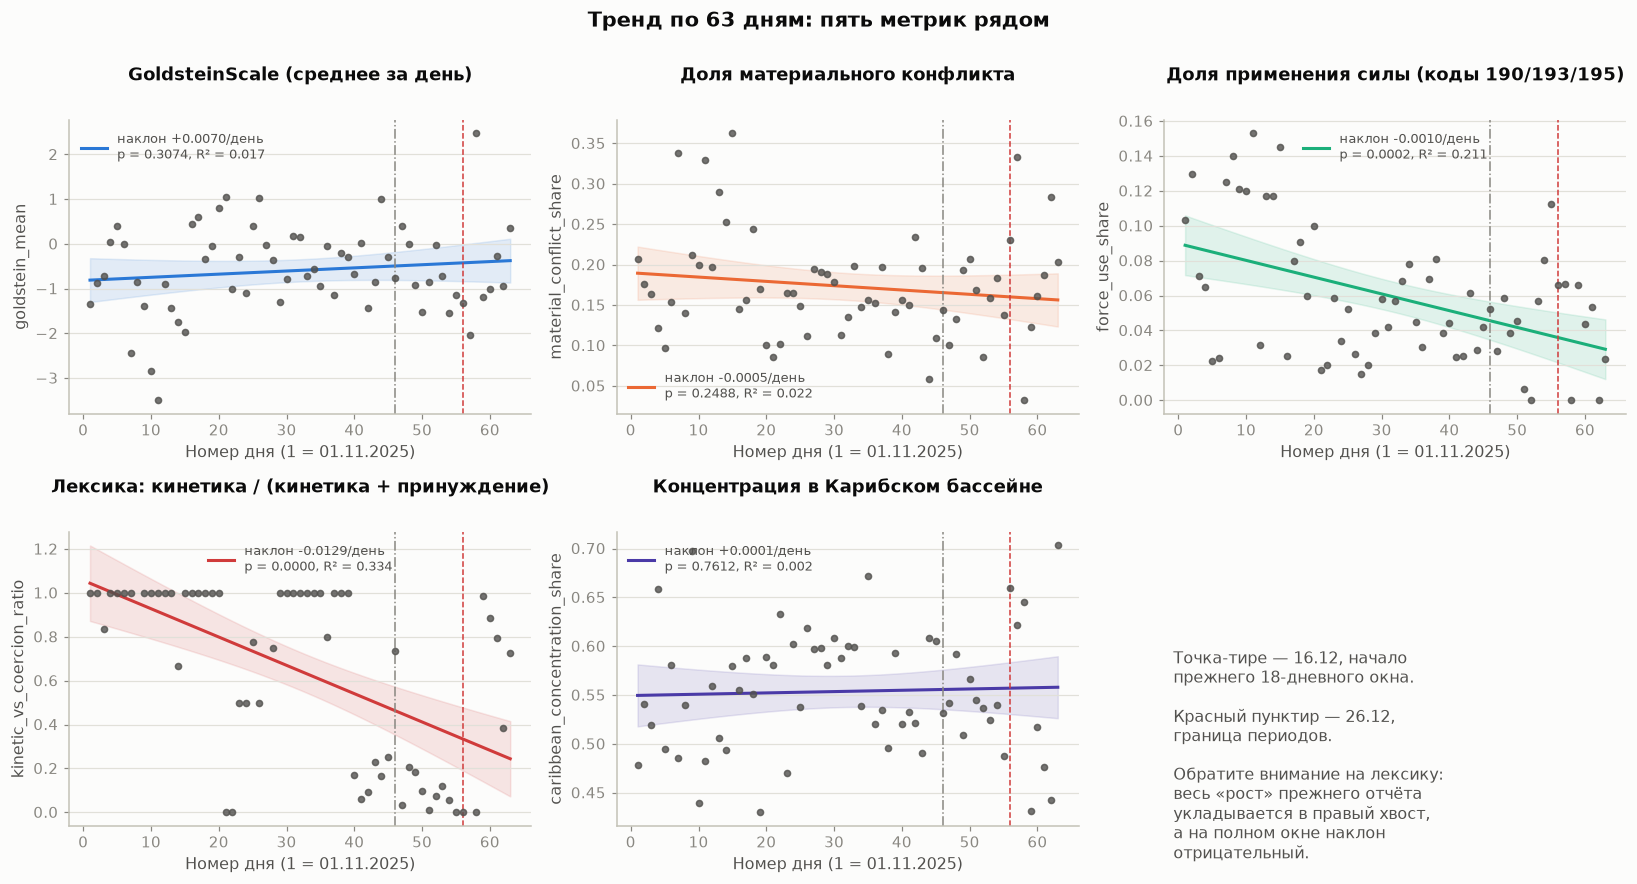

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = [BLUE, ORANGE, AQUA, CRITICAL, "#4a3aa7"]
for ax, (col, human), color in zip(axes.ravel(), TREND_SPECS, colors):
    ser = daily[col].dropna()
    x = daily.loc[ser.index, "day_number"].values.astype(float); y = ser.values
    fit = sm.OLS(y, sm.add_constant(x)).fit()
    pred = fit.get_prediction(sm.add_constant(x)).summary_frame(alpha=0.05)
    ax.fill_between(x, pred["mean_ci_lower"], pred["mean_ci_upper"], color=color, alpha=0.12)
    ax.plot(x, fit.fittedvalues, color=color, lw=2.0,
            label=f"наклон {fit.params[1]:+.4f}/день\np = {fit.pvalues[1]:.4f}, R² = {fit.rsquared:.3f}")
    ax.scatter(x, y, color=INK_2, s=16, zorder=3, alpha=0.8)
    ax.axvline(46, color=MUTED, lw=1.0, ls="-.")       # 16.12 — начало прежнего окна
    ax.axvline(56, color=CRITICAL, lw=1.0, ls="--")    # 26.12 — граница периодов
    ax.set_title(human, fontsize=11.5); ax.set_xlabel("Номер дня (1 = 01.11.2025)"); ax.set_ylabel(col)
    ax.legend(loc="best", fontsize=8.5)
axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(0.02, 0.6,
    "Точка-тире — 16.12, начало\nпрежнего 18-дневного окна.\n\n"
    "Красный пунктир — 26.12,\nграница периодов.\n\n"
    "Обратите внимание на лексику:\nвесь «рост» прежнего отчёта\n"
    "укладывается в правый хвост,\nа на полном окне наклон\nотрицательный.",
    fontsize=10.5, color=INK_2, va="top")
fig.suptitle("Тренд по 63 дням: пять метрик рядом", fontsize=14, fontweight="bold", color=INK, y=1.0)
plt.tight_layout(); plt.show()

**Вывод по гипотезе C — и это самый резкий разворот по сравнению с прошлым отчётом.**

На 63 днях значимые тренды появились, но **все они направлены против гипотезы эскалации**:

- `kinetic_vs_coercion_ratio`: наклон **−0,0129 в день**, p < 0,0001, R² = 0,334, тау = −0,46.
  На 18 днях наклон был **+0,031** (p = 0,061). Знак перевернулся, потому что короткое окно
  захватывало только правый хвост провала.
- `force_use_share`: наклон −0,0010/день, p = 0,0002, R² = 0,211 — доля применения силы
  **снижалась** на протяжении двух месяцев.
- `goldstein_mean`, `material_conflict_share`, `caribbean_concentration_share` — тренда нет
  (p = 0,31; 0,25; 0,76).

> **Простыми словами.** За два месяца до дня X новости не становились ни злее, ни «военнее» —
> наоборот, доля прямого применения силы и доля «ударной» лексики снижались. Всё, что в прошлом
> отчёте выглядело нарастанием, было подъёмом со дна локальной ямы.

### Поправка Бонферрони

In [19]:
res = pd.DataFrame(RESULTS)
m_tests, ALPHA = len(res), 0.05
res["p_bonferroni"] = np.minimum(res.p_value * m_tests, 1.0)
res["значим (α=0.05)"]       = np.where(res.p_value < ALPHA, "да", "нет")
res["значим после поправки"] = np.where(res.p_bonferroni < ALPHA, "да", "нет")
res["вывод"] = np.where(res.p_bonferroni < ALPHA, "H0 отвергается", "H0 не отвергается")
print(f"Тестов m = {m_tests} (A: 2, B: 2, C: 5) | порог α/m = {ALPHA/m_tests:.4f}\n")
display(res[["hypothesis", "metric", "test", "detail", "p_value", "p_bonferroni",
             "effect_name", "effect", "effect_size", "значим (α=0.05)", "значим после поправки"]]
        .rename(columns={"hypothesis": "гипотеза", "metric": "показатель", "test": "тест",
                         "detail": "сдвиг", "p_value": "p-value", "p_bonferroni": "p Бонферрони",
                         "effect_name": "мера", "effect": "размер эффекта", "effect_size": "интерпретация"})
        .style.format({"p-value": "{:.5f}", "p Бонферрони": "{:.5f}", "размер эффекта": "{:+.4f}"})
        .hide(axis="index"))

Тестов m = 9 (A: 2, B: 2, C: 5) | порог α/m = 0.0056



гипотеза,показатель,тест,сдвиг,p-value,p Бонферрони,мера,размер эффекта,интерпретация,значим (α=0.05),значим после поправки
A: сдвиг тона/интенсивности,GoldsteinScale,Манна-Уитни (двусторонний),среднее -0.481 → -0.699,0.03350,0.30153,Cohen's d,-0.0466,пренебрежимо малый,да,нет
A: сдвиг тона/интенсивности,AvgTone,Манна-Уитни (двусторонний),среднее -4.514 → -4.866,0.00307,0.02763,Cohen's d,-0.1301,пренебрежимо малый,да,да
B: рост доли конфликтных событий,material_conflict_share,z-тест пропорций (односторонний),доля 0.164 → 0.185,0.04931,0.44382,Cohen's h,+0.0532,пренебрежимо малый,да,нет
B: рост доли конфликтных событий,conflict_hard_share,z-тест пропорций (односторонний),доля 0.070 → 0.064,0.75890,1.00000,Cohen's h,-0.0235,пренебрежимо малый,нет,нет
C: наличие тренда во времени,goldstein_mean,"Линейная регрессия (МНК), наклон","наклон +0.00702/день, тау MK +0.003 (p=0.981)",0.30737,1.00000,R²,+0.0171,пренебрежимо малый,нет,нет
C: наличие тренда во времени,material_conflict_share,"Линейная регрессия (МНК), наклон","наклон -0.00053/день, тау MK -0.076 (p=0.383)",0.24877,1.00000,R²,+0.0217,малый,нет,нет
C: наличие тренда во времени,force_use_share,"Линейная регрессия (МНК), наклон","наклон -0.00096/день, тау MK -0.251 (p=0.004)",0.00015,0.00138,R²,+0.2108,средний,да,да
C: наличие тренда во времени,kinetic_vs_coercion_ratio,"Линейная регрессия (МНК), наклон","наклон -0.01290/день, тау MK -0.411 (p=0.000)",0.00000,0.00001,R²,+0.3340,большой,да,да
C: наличие тренда во времени,caribbean_concentration_share,"Линейная регрессия (МНК), наклон","наклон +0.00013/день, тау MK +0.030 (p=0.731)",0.76115,1.00000,R²,+0.0015,пренебрежимо малый,нет,нет


### Проверка устойчивости: кластеры по статье и уровень статьи

In [20]:
ROBUST = []
X_late = sm.add_constant(df.late_flag.values.astype(float))
print("1. КЛАСТЕРНЫЕ СТАНДАРТНЫЕ ОШИБКИ (кластер = SOURCEURL)")
print("=" * 92)
for col, human in [("GoldsteinScale", "GoldsteinScale"), ("AvgTone", "AvgTone"),
                   ("is_material_conf", "material_conflict_share"),
                   ("is_conflict_hard", "conflict_hard_share")]:
    y = df[col].values.astype(float)
    naive = sm.OLS(y, X_late).fit()
    clust = sm.OLS(y, X_late).fit(cov_type="cluster", cov_kwds={"groups": df.SOURCEURL.values})
    verdict = "совпадает" if (naive.pvalues[1] < 0.05) == (clust.pvalues[1] < 0.05) else "РАСХОДИТСЯ"
    print(f"{human:<24} эффект {naive.params[1]:+.4f} | p {naive.pvalues[1]:.4f} -> "
          f"кластерный {clust.pvalues[1]:.4f} | SE ×{clust.bse[1]/naive.bse[1]:.2f}  [{verdict}]")
    ROBUST.append(dict(метрика=human, эффект=naive.params[1], p_события=naive.pvalues[1],
                       p_кластеры=clust.pvalues[1], вердикт=verdict))

print("\n2. АГРЕГАЦИЯ ДО УРОВНЯ СТАТЬИ")
print("=" * 92)
by_article = df.groupby("SOURCEURL").agg(
    first_day=("date_added", "min"), goldstein=("GoldsteinScale", "mean"),
    tone=("AvgTone", "mean"), material_share=("is_material_conf", "mean"),
    hard_share=("is_conflict_hard", "mean"))
by_article["period"] = np.where(by_article.first_day >= SPLIT, "late", "early")
print(f"Статей: {len(by_article)} (ранний {int((by_article.period == 'early').sum())}, "
      f"поздний {int((by_article.period == 'late').sum())})\n")
for col, human in [("goldstein", "GoldsteinScale"), ("tone", "AvgTone"),
                   ("material_share", "material_conflict_share"), ("hard_share", "conflict_hard_share")]:
    early = by_article.loc[by_article.period == "early", col]
    late  = by_article.loc[by_article.period == "late",  col]
    U, p_art = stats.mannwhitneyu(late, early, alternative="two-sided")
    d_art = cohens_d(late, early)
    row = next(r for r in ROBUST if r["метрика"] == human)
    verdict = "совпадает" if (row["p_события"] < 0.05) == (p_art < 0.05) else "РАСХОДИТСЯ"
    print(f"{human:<24} {early.mean():+.4f} -> {late.mean():+.4f} | Манна-Уитни p = {p_art:.4f} | "
          f"d = {d_art:+.4f}  [{verdict}]")
    row["p_статьи"], row["d_статьи"] = p_art, d_art
    if verdict == "РАСХОДИТСЯ":
        row["вердикт"] = "РАСХОДИТСЯ"

display(pd.DataFrame(ROBUST).style.format({"эффект": "{:+.4f}", "p_события": "{:.4f}",
        "p_кластеры": "{:.4f}", "p_статьи": "{:.4f}", "d_статьи": "{:+.3f}"}).hide(axis="index"))

1. КЛАСТЕРНЫЕ СТАНДАРТНЫЕ ОШИБКИ (кластер = SOURCEURL)
GoldsteinScale           эффект -0.2178 | p 0.1555 -> кластерный 0.3842 | SE ×1.63  [совпадает]
AvgTone                  эффект -0.3518 | p 0.0001 -> кластерный 0.0353 | SE ×1.88  [совпадает]
material_conflict_share  эффект +0.0202 | p 0.0986 -> кластерный 0.3274 | SE ×1.69  [совпадает]
conflict_hard_share      эффект -0.0059 | p 0.4822 -> кластерный 0.6441 | SE ×1.52  [совпадает]

2. АГРЕГАЦИЯ ДО УРОВНЯ СТАТЬИ
Статей: 4202 (ранний 3835, поздний 367)

GoldsteinScale           -0.9068 -> -1.0970 | Манна-Уитни p = 0.1918 | d = -0.0443  [совпадает]
AvgTone                  -4.6130 -> -4.9457 | Манна-Уитни p = 0.0931 | d = -0.1185  [РАСХОДИТСЯ]
material_conflict_share  +0.1793 -> +0.2013 | Манна-Уитни p = 0.3589 | d = +0.0622  [совпадает]
conflict_hard_share      +0.0745 -> +0.0737 | Манна-Уитни p = 0.5502 | d = -0.0032  [совпадает]


метрика,эффект,p_события,p_кластеры,вердикт,p_статьи,d_статьи
GoldsteinScale,-0.2178,0.1555,0.3842,совпадает,0.1918,-0.044
AvgTone,-0.3518,0.0001,0.0353,РАСХОДИТСЯ,0.0931,-0.118
material_conflict_share,+0.0202,0.0986,0.3274,совпадает,0.3589,+0.062
conflict_hard_share,-0.0059,0.4822,0.6441,совпадает,0.5502,-0.003


**Вывод по разделу 6.** При 9 тестах порог Бонферрони α/m = 0,0056. Его переживает **только
`AvgTone`** (p = 0,0031 → 0,0279) и два теста тренда, направленных **против** гипотезы
(лексика и доля применения силы — оба со снижением).

Проверка устойчивости для `AvgTone` даёт смешанный результат, и его надо проговорить честно:
- с **кластерными ошибками** по `SOURCEURL` сдвиг сохраняется: p = 0,035 (стандартная ошибка
  выросла в 1,88 раза, но эффект устоял);
- на **уровне статьи** (Манна-Уитни, 3 835 против 367 статей) — p = 0,093, то есть значимость
  теряется, хотя размер эффекта почти не меняется (d = −0,119 против −0,130).

Это не опровержение, но и не чистое подтверждение: тест на уровне статьи консервативнее (мы
теряем информацию о том, что одна статья могла породить десяток конфликтных записей), и при
резко несбалансированных группах он менее чувствителен. Правильная формулировка: **сдвиг тона
устойчив к учёту зависимости строк, но находится на границе разрешающей способности данных.**
`material_conflict_share`, как и на 18 днях, кластеризации не переживает (p = 0,33).

> **Простыми словами.** Из всего набора метрик до финиша дошла одна: тон публикаций. Он и
> значимо мрачнее в последнюю неделю, и остаётся значимым, когда мы перестаём считать несколько
> записей об одной статье независимыми, и по скользящим окнам показывает рекорд за два месяца.
> Всё остальное либо не отличается от фона, либо движется в обратную сторону.

---
## 7. Визуализация

### 7.1 Тон и GoldsteinScale за 63 дня

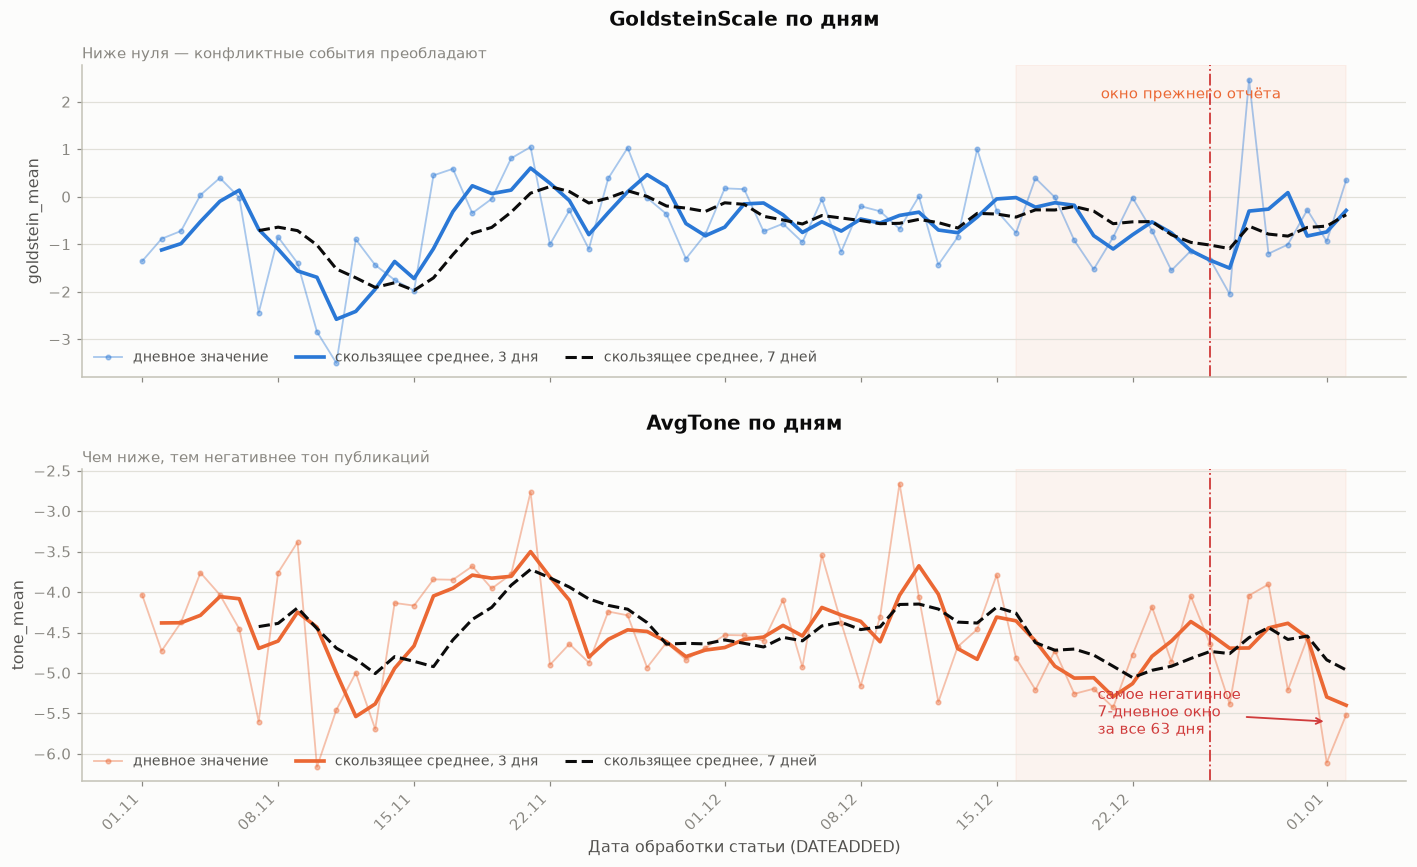

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, (col, roll, rstd, color, title, sub) in zip(axes, [
        ("goldstein_mean", "roll3_mean_goldstein_mean", "roll3_std_goldstein_mean", BLUE,
         "GoldsteinScale по дням", "Ниже нуля — конфликтные события преобладают"),
        ("tone_mean", "roll3_mean_tone_mean", "roll3_std_tone_mean", ORANGE,
         "AvgTone по дням", "Чем ниже, тем негативнее тон публикаций")]):
    ax.plot(daily.index, daily[col], color=color, alpha=0.40, lw=1.2, marker="o", markersize=3,
            label="дневное значение")
    ax.plot(daily.index, daily[roll], color=color, lw=2.4, label="скользящее среднее, 3 дня")
    ax.plot(daily.index, daily[col].rolling(7).mean(), color=INK, lw=2.0, ls="--",
            label="скользящее среднее, 7 дней")
    ax.axvspan(W18, daily.index.max(), color=ORANGE, alpha=0.06)
    ax.axvline(SPLIT, color=CRITICAL, lw=1.2, ls="-.")
    ax.set_title(title); subtitle(ax, sub); ax.set_ylabel(col)
    ax.legend(ncol=3, loc="lower left", fontsize=9)
axes[0].annotate("окно прежнего отчёта", xy=(pd.Timestamp("2025-12-25"), axes[0].get_ylim()[1] * 0.75),
                 color=ORANGE, fontsize=9.5, ha="center")
axes[1].annotate("самое негативное\n7-дневное окно\nза все 63 дня",
                 xy=(pd.Timestamp("2026-01-01"), -5.6), xytext=(-150, -8), textcoords="offset points",
                 color=CRITICAL, fontsize=9.5,
                 arrowprops=dict(arrowstyle="->", color=CRITICAL, lw=1.2))
axes[1].set_xlabel("Дата обработки статьи (DATEADDED)")
axes[1].xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(h_pad=2.0); plt.show()

**Вывод.** Семидневная линия (чёрный пунктир) на нижней панели к концу окна уходит вниз и
достигает минимума за весь период. На верхней панели у `GoldsteinScale` ничего похожего нет —
он колеблется в одном и том же коридоре все два месяца. Это визуальное подтверждение того, что
из двух «тональных» метрик работает только одна.

### 7.2 Лексика: главный разворот по сравнению с прошлым отчётом

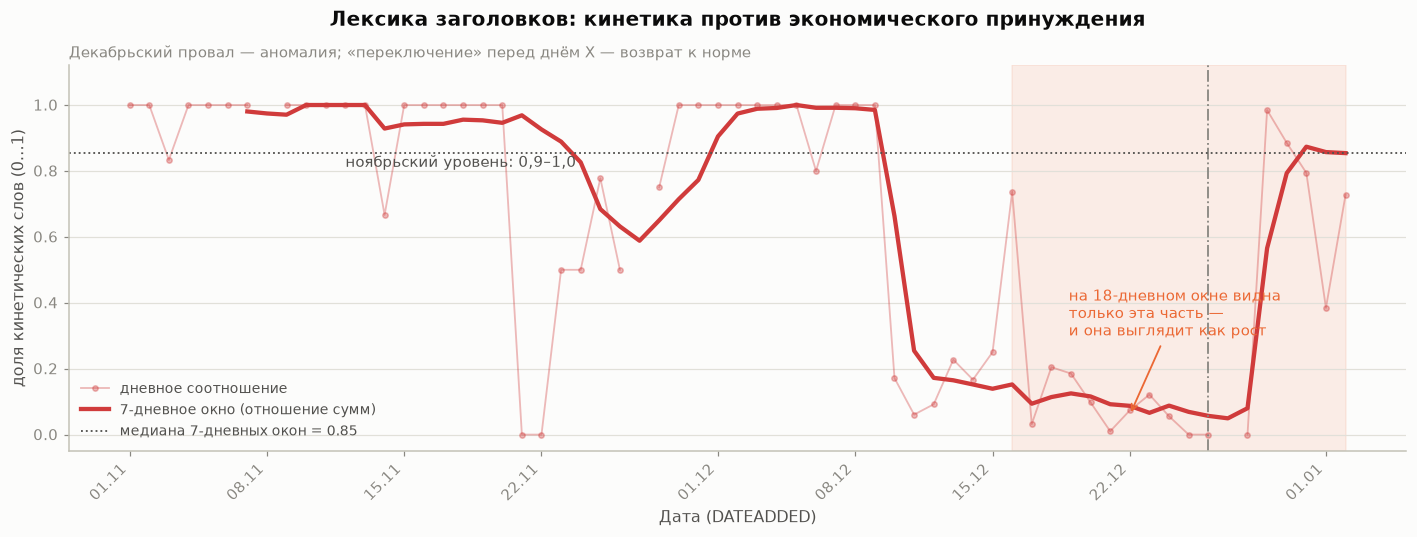

In [22]:
ratio7 = (daily.kinetic_words.rolling(7).sum() /
          (daily.kinetic_words.rolling(7).sum() + daily.coercion_words.rolling(7).sum()))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily.index, daily.kinetic_vs_coercion_ratio, color=CRITICAL, alpha=0.35, lw=1.2,
        marker="o", markersize=3.5, label="дневное соотношение")
ax.plot(ratio7.index, ratio7, color=CRITICAL, lw=2.8, label="7-дневное окно (отношение сумм)")
ax.axvspan(W18, daily.index.max(), color=ORANGE, alpha=0.10)
ax.axvline(SPLIT, color=MUTED, lw=1.2, ls="-.")
ax.axhline(ratio7.median(), color=INK_2, lw=1.2, ls=":", label=f"медиана 7-дневных окон = {ratio7.median():.2f}")
ax.annotate("на 18-дневном окне видна\nтолько эта часть —\nи она выглядит как рост",
            xy=(pd.Timestamp("2025-12-22"), 0.06), xytext=(-40, 52), textcoords="offset points",
            color=ORANGE, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.2))
ax.annotate("ноябрьский уровень: 0,9–1,0", xy=(pd.Timestamp("2025-11-12"), 0.97),
            xytext=(0, -34), textcoords="offset points", color=INK_2, fontsize=9.5)
ax.set_title("Лексика заголовков: кинетика против экономического принуждения")
subtitle(ax, "Декабрьский провал — аномалия; «переключение» перед днём X — возврат к норме")
ax.set_xlabel("Дата (DATEADDED)"); ax.set_ylabel("доля кинетических слов (0…1)")
ax.set_ylim(-0.05, 1.12); ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

**Вывод.** Это тот график, ради которого стоило брать 60 дней. Оранжевая зона — всё, что было
видно в прошлом отчёте. Внутри неё показатель действительно идёт снизу вверх, и на 18 днях это
читалось как «переключение на язык ударов перед вторжением». На полном окне видно, что нормой
был как раз высокий уровень (ноябрь: 0,9–1,0), а декабрьский провал до 0,05 — это период, когда
повестку заняли танкеры, нефть и блокада. Конец декабря — просто возвращение к прежнему языку.

### 7.3 Сравнение периодов

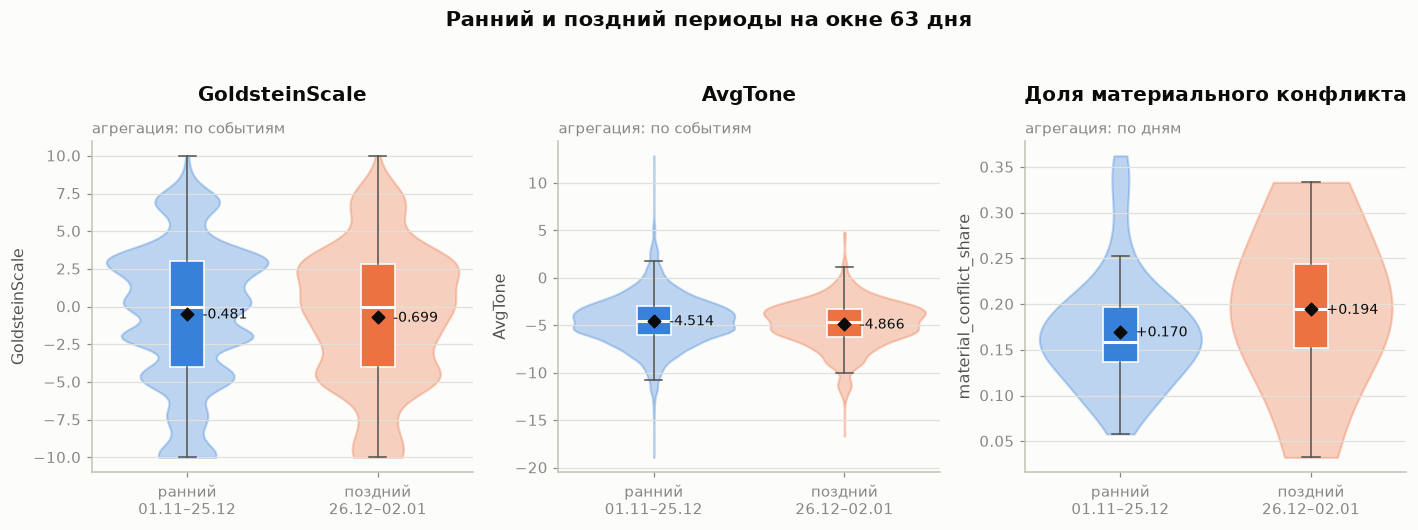

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (col, source, human, level) in zip(axes, [
        ("GoldsteinScale", df, "GoldsteinScale", "по событиям"),
        ("AvgTone", df, "AvgTone", "по событиям"),
        ("material_conflict_share", daily, "Доля материального конфликта", "по дням")]):
    data = [source.loc[source.period == "early", col].dropna().values,
            source.loc[source.period == "late",  col].dropna().values]
    vp = ax.violinplot(data, showextrema=False, widths=0.85)
    for body, c in zip(vp["bodies"], [BLUE, ORANGE]):
        body.set(facecolor=c, alpha=0.30, edgecolor=c, linewidth=1.4)
    bp = ax.boxplot(data, widths=0.18, patch_artist=True, showfliers=False)
    for box, c in zip(bp["boxes"], [BLUE, ORANGE]):
        box.set(facecolor=c, alpha=0.9, edgecolor=SURFACE, linewidth=1.2)
    for el in ("whiskers", "caps"): [ln.set(color=INK_2, lw=1.0) for ln in bp[el]]
    for med in bp["medians"]: med.set(color=SURFACE, lw=2.0)
    for i, arr in enumerate(data, start=1):
        ax.scatter([i], [arr.mean()], color=INK, s=34, zorder=5, marker="D")
        ax.annotate(f"{arr.mean():+.3f}", xy=(i, arr.mean()), xytext=(10, -3),
                    textcoords="offset points", fontsize=9, color=INK)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["ранний\n01.11–25.12", "поздний\n26.12–02.01"])
    ax.set_title(human); subtitle(ax, f"агрегация: {level}"); ax.set_ylabel(col)
fig.suptitle("Ранний и поздний периоды на окне 63 дня", fontsize=13.5, fontweight="bold",
             color=INK, y=1.04)
plt.tight_layout(); plt.show()

### 7.4 Скользящие окна: где стоит последняя неделя

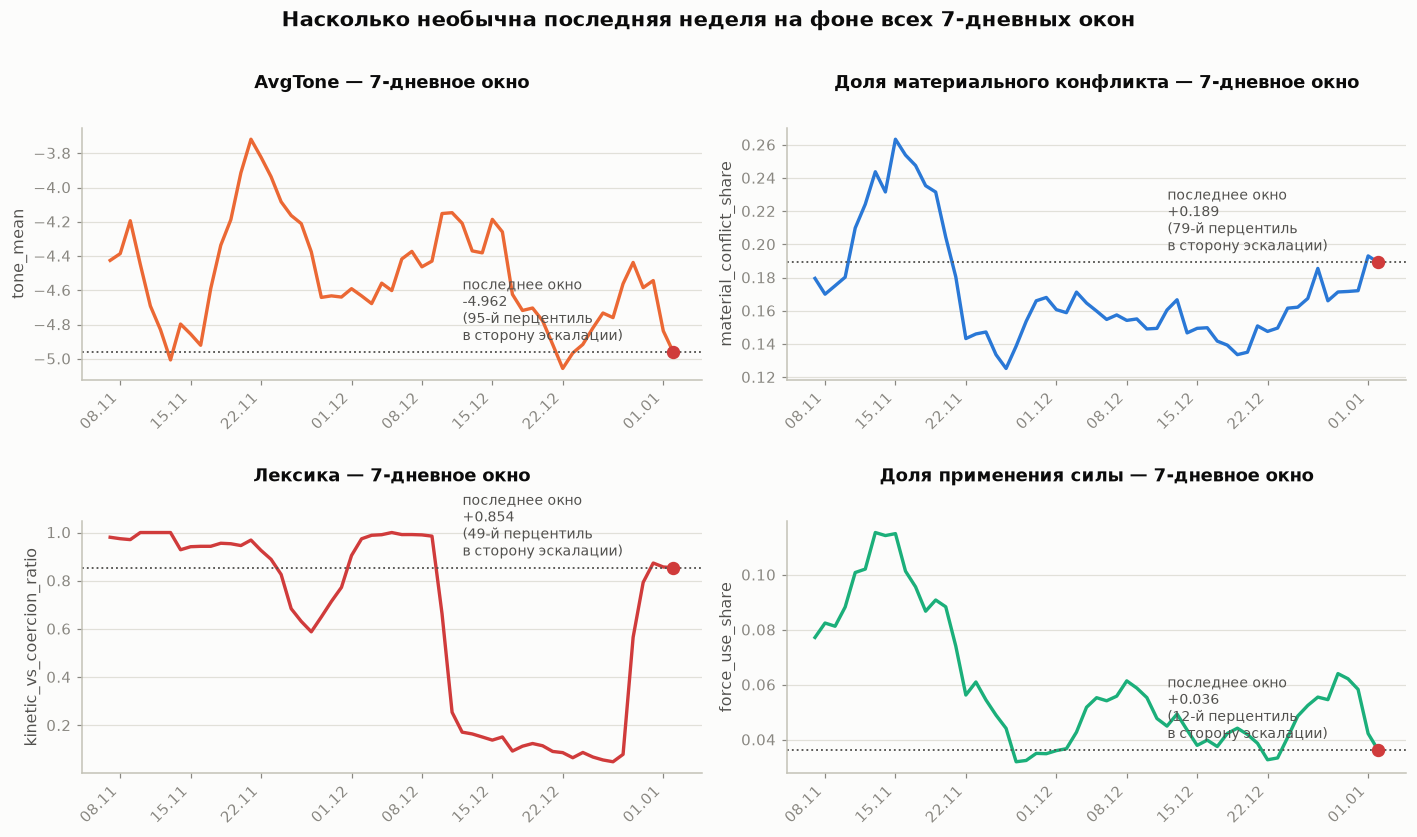

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
panels = [("tone_mean", "AvgTone — 7-дневное окно", ORANGE, "ниже"),
          ("material_conflict_share", "Доля материального конфликта — 7-дневное окно", BLUE, "выше"),
          ("kinetic_vs_coercion_ratio", "Лексика — 7-дневное окно", CRITICAL, "выше"),
          ("force_use_share", "Доля применения силы — 7-дневное окно", AQUA, "выше")]
for ax, (col, title, color, direction) in zip(axes.ravel(), panels):
    ser = roll7[col]
    ax.plot(ser.index, ser.values, color=color, lw=2.2)
    last = ser.iloc[-1]
    ax.axhline(last, color=INK_2, ls=":", lw=1.2)
    ax.scatter([ser.index[-1]], [last], color=CRITICAL, s=60, zorder=5)
    pct = (ser < last).mean() * 100
    signal = pct if direction == "выше" else 100 - pct
    ax.annotate(f"последнее окно\n{last:+.3f}\n({signal:.0f}-й перцентиль\nв сторону эскалации)",
                xy=(ser.index[-1], last), xytext=(-138, 8), textcoords="offset points",
                fontsize=9, color=INK_2)
    ax.set_title(title, fontsize=11.5); ax.set_ylabel(col)
    ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
    for lbl in ax.get_xticklabels(): lbl.set_rotation(45); lbl.set_ha("right")
fig.suptitle("Насколько необычна последняя неделя на фоне всех 7-дневных окон",
             fontsize=13.5, fontweight="bold", color=INK, y=1.01)
plt.tight_layout(h_pad=2.2); plt.show()

**Вывод.** Только на панели `AvgTone` красная точка уходит к нижней границе всего диапазона.
На остальных трёх она сидит в середине или даже ниже среднего. Именно так выглядит разница
между «метрика сигналит» и «метрика просто колеблется».

### 7.5 Корреляции метрик

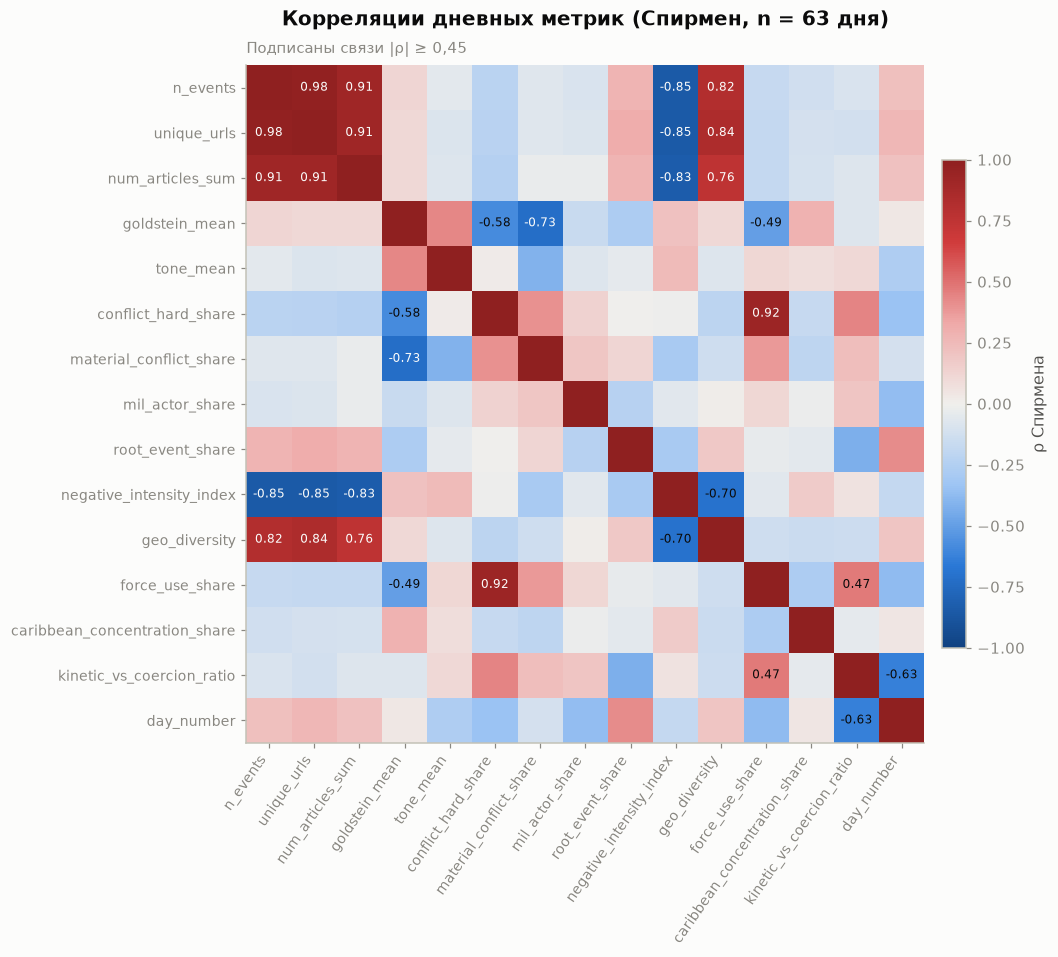

Связь со временем (day_number):


,ρ
kinetic_vs_coercion_ratio,-0.6280
force_use_share,-0.3730
mil_actor_share,-0.3650
conflict_hard_share,-0.3390
tone_mean,-0.2620
negative_intensity_index,-0.1750
material_conflict_share,-0.1110
goldstein_mean,0.0320
caribbean_concentration_share,0.0470
geo_diversity,0.2020


In [25]:
corr_cols = ["n_events", "unique_urls", "num_articles_sum", "goldstein_mean", "tone_mean",
             "conflict_hard_share", "material_conflict_share", "mil_actor_share", "root_event_share",
             "negative_intensity_index", "geo_diversity", "force_use_share",
             "caribbean_concentration_share", "kinetic_vs_coercion_ratio", "day_number"]
C = daily[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10.5, 8.8))
im = ax.imshow(C.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = C.values[i, j]
        if i != j and abs(v) >= 0.45:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.6,
                    color=SURFACE if abs(v) > 0.72 else INK)
ax.set_title("Корреляции дневных метрик (Спирмен, n = 63 дня)")
subtitle(ax, "Подписаны связи |ρ| ≥ 0,45")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02); cb.set_label("ρ Спирмена", color=INK_2)
plt.tight_layout(); plt.show()
print("Связь со временем (day_number):")
display(C["day_number"].drop("day_number").sort_values().to_frame("ρ").round(3))

### 7.6 Облака слов: ноябрь, декабрь до 26-го, последняя неделя

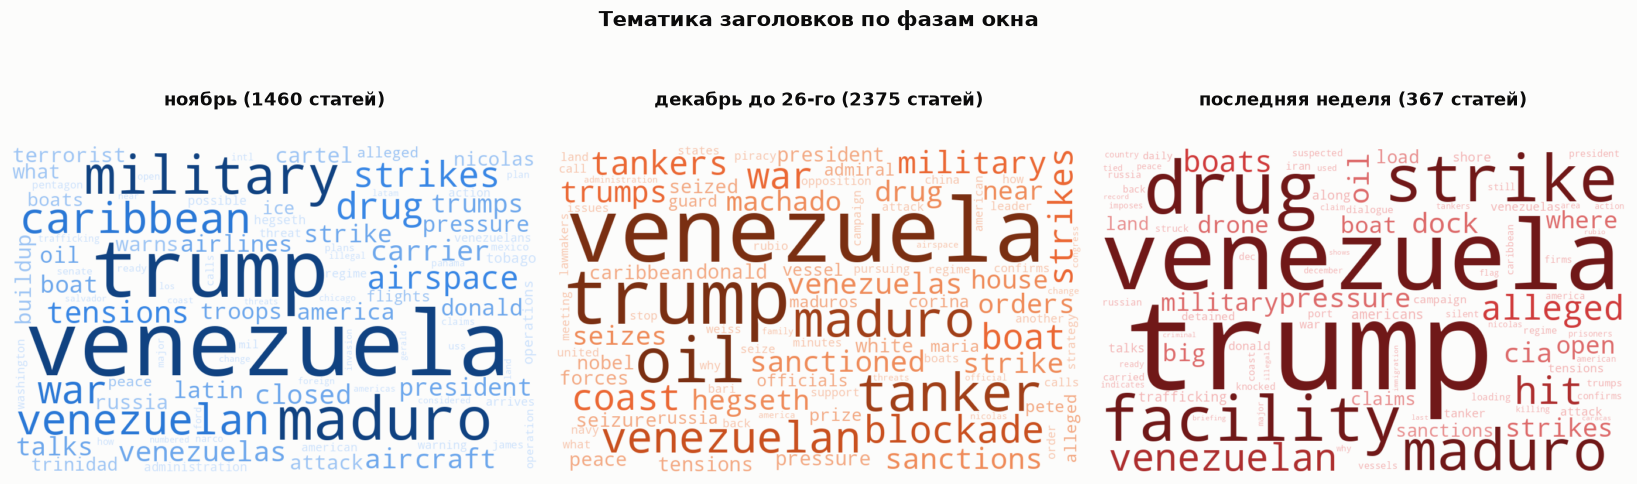

Слова, усилившиеся к последней неделе относительно НОЯБРЯ:


,слово,"ноябрь, ‰","декабрь до 26-го, ‰","последняя неделя, ‰","сдвиг ноябрь→последняя, ‰"
0,drug,8.4100,5.6400,29.2900,20.8800
1,facility,0.1200,0.0000,20.7300,20.6100
2,strike,3.9200,5.3000,22.5300,18.6100
3,hit,0.2300,0.4000,13.9700,13.7400
4,trump,47.8200,46.6600,58.5800,10.7600
5,alleged,2.4200,2.3500,13.0700,10.6500
6,dock,0.0000,0.0000,8.5600,8.5600
7,cia,0.6900,0.2000,8.1100,7.4200
8,boats,2.6500,1.9500,9.9100,7.2600
9,drone,0.0000,0.2700,6.3100,6.3100


Слова, ослабевшие:


,слово,"ноябрь, ‰","декабрь до 26-го, ‰","последняя неделя, ‰","сдвиг ноябрь→последняя, ‰"
0,military,18.5500,6.7100,6.7600,-11.7900
1,caribbean,11.2900,3.9600,2.2500,-9.0400
2,maduro,23.7400,18.8000,16.6700,-7.0600
3,venezuela,62.9200,66.2000,57.2300,-5.6800
4,airspace,6.1100,1.4100,0.4500,-5.6600
5,war,9.4500,9.6700,4.0600,-5.3900
6,carrier,5.1900,0.2000,0.0000,-5.1900
7,aircraft,4.7200,0.2700,0.4500,-4.2700
8,closed,4.6100,0.5400,0.4500,-4.1600
9,airlines,3.6900,0.2000,0.0000,-3.6900


In [26]:
uniq = df.drop_duplicates(subset="SOURCEURL").copy()
uniq["phase"] = np.where(uniq.date_added < pd.Timestamp("2025-12-01"), "ноябрь",
                 np.where(uniq.date_added < SPLIT, "декабрь до 26-го", "последняя неделя"))
counts = {ph: Counter(w for ws in sub.slug_words for w in ws)
          for ph, sub in uniq.groupby("phase")}

def color_ramp(ramp):
    def f(word, font_size, position, orientation, random_state=None, **kw):
        idx = int(np.clip((font_size - 12) / 78 * (len(ramp) - 1), 0, len(ramp) - 1))
        return ramp[idx]
    return f
RAMPS = {"ноябрь": SEQ_BLUE,
         "декабрь до 26-го": ["#f7c6ae", "#f3a983", "#ef8b59", "#eb6834", "#c9501f", "#a03f18", "#7a2f12"],
         "последняя неделя": ["#f3b5b5", "#e88f8f", "#dd6a6a", "#d03b3b", "#ad2e2e", "#8f2020", "#701818"]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, ph in zip(axes, ["ноябрь", "декабрь до 26-го", "последняя неделя"]):
    wc = WordCloud(width=900, height=560, background_color=SURFACE, prefer_horizontal=0.95,
                   max_words=90, relative_scaling=0.5, random_state=7,
                   color_func=color_ramp(RAMPS[ph]), margin=4).generate_from_frequencies(counts[ph])
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title(f"{ph} ({len(uniq[uniq.phase == ph])} статей)", fontsize=12)
fig.suptitle("Тематика заголовков по фазам окна", fontsize=13.5, fontweight="bold", color=INK, y=1.03)
plt.tight_layout(); plt.show()

tot = {ph: sum(c.values()) for ph, c in counts.items()}
vocab = {w for c in counts.values() for w, n in c.items() if n >= 12}
sh = pd.DataFrame({"слово": sorted(vocab)})
for ph in ["ноябрь", "декабрь до 26-го", "последняя неделя"]:
    sh[ph + ", ‰"] = [counts[ph].get(w, 0) / tot[ph] * 1000 for w in sh.слово]
sh["сдвиг ноябрь→последняя, ‰"] = sh["последняя неделя, ‰"] - sh["ноябрь, ‰"]
print("Слова, усилившиеся к последней неделе относительно НОЯБРЯ:")
display(sh.sort_values("сдвиг ноябрь→последняя, ‰", ascending=False).head(12).round(2).reset_index(drop=True))
print("Слова, ослабевшие:")
display(sh.sort_values("сдвиг ноябрь→последняя, ‰").head(12).round(2).reset_index(drop=True))

**Вывод.** Три облака показывают то же, что и числовая метрика: ноябрь и последняя неделя
лексически **похожи друг на друга больше**, чем любой из них похож на середину декабря. В ноябре
и в конце декабря — удары, лодки, наркотики, военные; в середине декабря — танкеры, нефть,
блокада, санкции. То есть «военная» рамка была нормой для этого сюжета почти всё окно, а
декабрьский эпизод с захватами танкеров был временным отклонением от неё.

---
## 8. Что изменилось против 18-дневной версии

In [27]:
# Числа 18-дневной версии вписаны вручную из прежнего отчёта — для прямого сравнения
prev = {
    ("A", "GoldsteinScale"):          dict(p=0.1104, eff=-0.0431, note="d"),
    ("A", "AvgTone"):                 dict(p=0.0512, eff=+0.0176, note="d"),
    ("B", "material_conflict_share"): dict(p=0.00145, eff=+0.1071, note="h"),
    ("B", "conflict_hard_share"):     dict(p=0.0964, eff=+0.0469, note="h"),
    ("C", "goldstein_mean"):          dict(p=0.8457, eff=+0.0024, note="R²"),
    ("C", "material_conflict_share"): dict(p=0.2285, eff=+0.0892, note="R²"),
    ("C", "force_use_share"):         dict(p=0.7867, eff=+0.0047, note="R²"),
    ("C", "kinetic_vs_coercion_ratio"): dict(p=0.0605, eff=+0.2155, note="R²"),
    ("C", "caribbean_concentration_share"): dict(p=0.9355, eff=+0.0004, note="R²"),
}
rows = []
for _, r in res.iterrows():
    key = (r.hypothesis[0], r.metric)
    if key not in prev:
        continue
    old = prev[key]
    rows.append(dict(гипотеза=key[0], метрика=r.metric, мера=old["note"],
                     p_18д=old["p"], p_63д=r.p_value,
                     эффект_18д=old["eff"], эффект_63д=r.effect,
                     значим_18д="да" if old["p"] < 0.05 else "нет",
                     значим_63д="да" if r.p_value < 0.05 else "нет"))
cmp = pd.DataFrame(rows)
cmp["изменение"] = np.where(cmp.значим_18д != cmp.значим_63д, "ВЕРДИКТ ИЗМЕНИЛСЯ", "вердикт тот же")
display(cmp.style.format({"p_18д": "{:.4f}", "p_63д": "{:.5f}",
                          "эффект_18д": "{:+.4f}", "эффект_63д": "{:+.4f}"}).hide(axis="index"))

гипотеза,метрика,мера,p_18д,p_63д,эффект_18д,эффект_63д,значим_18д,значим_63д,изменение
A,GoldsteinScale,d,0.1104,0.03350,-0.0431,-0.0466,нет,да,ВЕРДИКТ ИЗМЕНИЛСЯ
A,AvgTone,d,0.0512,0.00307,+0.0176,-0.1301,нет,да,ВЕРДИКТ ИЗМЕНИЛСЯ
B,material_conflict_share,h,0.0014,0.04931,+0.1071,+0.0532,да,да,вердикт тот же
B,conflict_hard_share,h,0.0964,0.75890,+0.0469,-0.0235,нет,нет,вердикт тот же
C,goldstein_mean,R²,0.8457,0.30737,+0.0024,+0.0171,нет,нет,вердикт тот же
C,material_conflict_share,R²,0.2285,0.24877,+0.0892,+0.0217,нет,нет,вердикт тот же
C,force_use_share,R²,0.7867,0.00015,+0.0047,+0.2108,нет,да,ВЕРДИКТ ИЗМЕНИЛСЯ
C,kinetic_vs_coercion_ratio,R²,0.0605,0.00000,+0.2155,+0.3340,нет,да,ВЕРДИКТ ИЗМЕНИЛСЯ
C,caribbean_concentration_share,R²,0.9355,0.76115,+0.0004,+0.0015,нет,нет,вердикт тот же


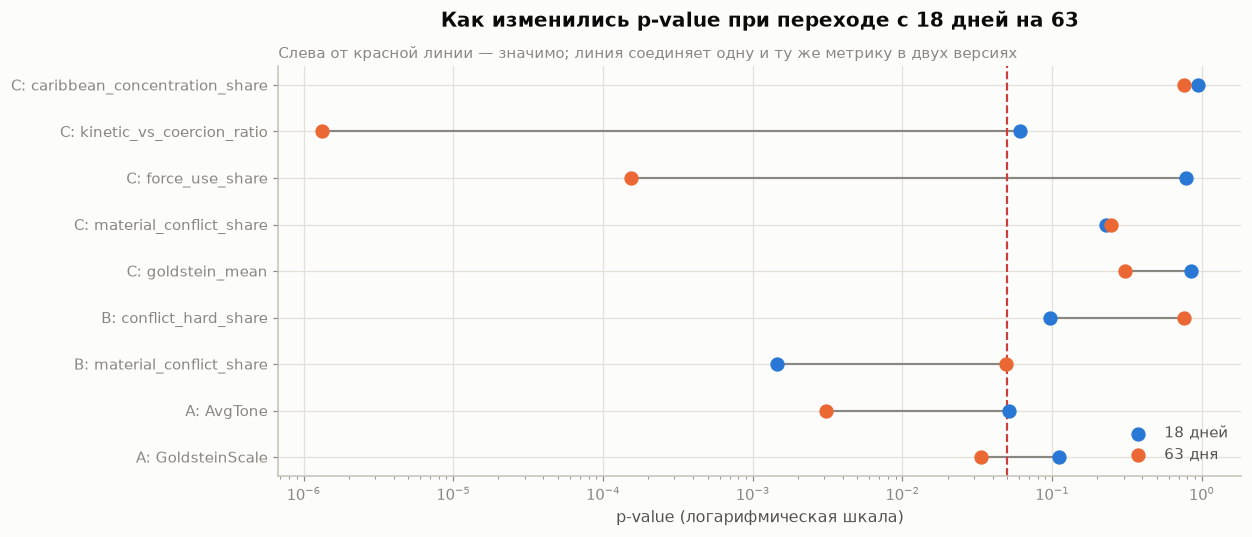

In [28]:
# Наглядно: как изменились p-value
fig, ax = plt.subplots(figsize=(11.5, 5))
y = np.arange(len(cmp))
ax.hlines(y, cmp.p_18д, cmp.p_63д, color=MUTED, lw=1.4, zorder=2)
ax.scatter(cmp.p_18д, y, color=BLUE, s=70, zorder=3, label="18 дней")
ax.scatter(cmp.p_63д, y, color=ORANGE, s=70, zorder=3, label="63 дня")
ax.axvline(0.05, color=CRITICAL, lw=1.4, ls="--")
ax.annotate("α = 0,05", xy=(0.05, len(cmp) - 0.4), xytext=(6, 0), textcoords="offset points",
            color=CRITICAL, fontsize=9.5)
ax.set_yticks(y); ax.set_yticklabels([f"{r.гипотеза}: {r.метрика}" for _, r in cmp.iterrows()], fontsize=9.5)
ax.set_xscale("log"); ax.set_xlabel("p-value (логарифмическая шкала)")
ax.set_title("Как изменились p-value при переходе с 18 дней на 63")
subtitle(ax, "Слева от красной линии — значимо; линия соединяет одну и ту же метрику в двух версиях")
ax.legend(loc="lower right"); ax.grid(axis="x")
plt.tight_layout(); plt.show()

**Что устояло, что рассыпалось, что появилось.**

| Результат 18-дневной версии | Что стало на 63 днях |
|---|---|
| Тон (`AvgTone`) не сдвинулся, d = +0,018 | **Сдвинулся: d = −0,130, p = 0,003, переживает Бонферрони (0,028) и кластерные ошибки (0,035); на уровне статьи p = 0,093** |
| `GoldsteinScale` не сдвинулся | Так и не сдвинулся (d = −0,047) |
| Рост `material_conflict_share` значим (p = 0,0015) | **Ослаб вдвое, p = 0,049, после поправки не значим** |
| Рост `conflict_hard_share` незначим | Развернулся в снижение (7,0 % → 6,4 %) |
| Лексика — «самый чёткий сигнал», наклон +0,031/день | **Знак перевернулся: −0,0129/день, p < 0,0001** |
| Тренда нет ни у чего | Тренды есть — и оба значимых направлены против эскалации |
| Объём освещения упал (праздники) | Подтвердилось: последняя неделя — 33-й перцентиль по объёму |

Три вывода из самого факта расхождения:

1. **Короткое окно опаснее отсутствия данных.** На 18 днях мы получили «значимый» рост доли
   конфликта и красивую историю про переключение словаря. Оба результата были следствием того,
   где случайно начиналось окно. Не будь ноября, мы бы этого не узнали и отчёт звучал бы
   увереннее — и был бы при этом менее верным.
2. **Направление ошибки предсказуемо.** Короткое окно систематически принимает **возврат к
   норме за эскалацию**, потому что не знает, где норма. Любой индикатор «изменение за последние
   N дней» без длинной базы уязвим ровно так же.
3. **Единственный сигнал нашёлся там, где его на коротком окне не было.** `AvgTone` требует
   длинной базы именно потому, что его сдвиг мал: 0,35 пункта не видно на фоне двухнедельного
   шума, но видно на фоне двухмесячного.

---
## 9. Выводы

In [29]:
print("=" * 100)
print("ИТОГОВАЯ СВОДКА — 63 ДНЯ")
print("=" * 100)
print(f"Окно: {df.date_added.min().date()} — {df.date_added.max().date()} "
      f"({daily.shape[0]} дней) | день X: 2026-01-03, в данных отсутствует")
print(f"События: {len(df):,} строк / {df.SOURCEURL.nunique():,} статей "
      f"({len(df)/df.SOURCEURL.nunique():.2f} строки на статью)")
print(f"Ранний период: {int((df.period == 'early').sum()):,} событий за "
      f"{int((daily.period == 'early').sum())} дней | поздний: "
      f"{int((df.period == 'late').sum()):,} за {int((daily.period == 'late').sum())}")
print("-" * 100)
for _, r in res.iterrows():
    mark = "ЗНАЧИМО" if r.p_bonferroni < 0.05 else "не значимо"
    print(f"{r.hypothesis[0]} | {r.metric:<30} p={r.p_value:.5f} | p_bonf={r.p_bonferroni:.4f} "
          f"| {r.effect_name}={r.effect:+.3f} | {mark}")
print("-" * 100)
print("Скользящие окна: последняя неделя экстремальна только по AvgTone (5-й перцентиль снизу)")
print("=" * 100)

ИТОГОВАЯ СВОДКА — 63 ДНЯ
Окно: 2025-11-01 — 2026-01-02 (63 дней) | день X: 2026-01-03, в данных отсутствует
События: 11,505 строк / 4,202 статей (2.74 строки на статью)
Ранний период: 10,487 событий за 55 дней | поздний: 1,018 за 8
----------------------------------------------------------------------------------------------------
A | GoldsteinScale                 p=0.03350 | p_bonf=0.3015 | Cohen's d=-0.047 | не значимо
A | AvgTone                        p=0.00307 | p_bonf=0.0276 | Cohen's d=-0.130 | ЗНАЧИМО
B | material_conflict_share        p=0.04931 | p_bonf=0.4438 | Cohen's h=+0.053 | не значимо
B | conflict_hard_share            p=0.75890 | p_bonf=1.0000 | Cohen's h=-0.023 | не значимо
C | goldstein_mean                 p=0.30737 | p_bonf=1.0000 | R²=+0.017 | не значимо
C | material_conflict_share        p=0.24877 | p_bonf=1.0000 | R²=+0.022 | не значимо
C | force_use_share                p=0.00015 | p_bonf=0.0014 | R²=+0.211 | ЗНАЧИМО
C | kinetic_vs_coercion_ratio      p=0.0000

### 9.1 По гипотезам

**A — сдвиг тона: частично подтвердилась.** `AvgTone` стал значимо негативнее
(−4,514 → −4,866; p = 0,0031; после Бонферрони 0,028; Cohen's d = −0,130 — формально ниже порога
«малого», но в семь раз больше, чем на 18 днях, и в нужную сторону). Результат держится при
кластерных ошибках (p = 0,035) и подтверждается скользящими окнами (рекорд за 63 дня), но на
уровне статьи не дотягивает до значимости (p = 0,093). `GoldsteinScale` не сдвинулся (d = −0,047).
→ *Из всех проверенных показателей единственный, который в последнюю неделю повёл себя необычно, —
тон публикаций. Эффект небольшой, но устойчивый ко всем проверкам.*

**B — рост доли конфликтных событий: не подтвердилась.** На длинной базе прибавка сжалась с
+4,0 до +2,0 п.п., p = 0,049 (на грани), после поправки Бонферрони не значима, при кластерных
ошибках p = 0,33. `conflict_hard_share` вовсе развернулся в снижение.
→ *То, что на коротком окне выглядело ростом конфликтности, было возвращением к обычному
ноябрьскому уровню.*

**C — тренд: не подтвердилась, а два значимых тренда направлены против гипотезы.**
Лексика: −0,0129/день (p < 0,0001, R² = 0,334). Доля применения силы: −0,0010/день (p = 0,0002,
R² = 0,211). Остальные три метрики тренда не имеют.
→ *За два месяца перед днём X освещение не «разогревалось». По двум метрикам оно, наоборот,
остывало.*

### 9.2 Главный содержательный итог

**Гипотеза «интенсивность освещения эскалации предсказывает агрессию» в этом кейсе снова не
подтверждается — но причина отказа изменилась.** На 18 днях мы не нашли сигнала из-за нехватки
данных. На 63 днях данных достаточно, и видно, что сигнала нет по существу: объём освещения в
последнюю неделю ниже медианы, доля конфликтных событий в пределах обычного разброса, доля
применения силы снижается, лексика возвращается к ноябрьской норме.

Исключение одно — **тон**. Последние семь дней перед захватом Мадуро дали самое негативное
7-дневное окно за все 63 дня (−4,96 при медиане около −4,5 и диапазоне до −3,72). Это
единственный кандидат в предикторы, переживший поправку на множественность, кластерные ошибки и
сравнение со всеми скользящими окнами. Оговорка: на уровне статьи он даёт p = 0,093 — то есть
находится на границе разрешающей способности данных, а не является твёрдым результатом.

Оговорка, без которой этот вывод не работает: **одно окно-рекорд за два месяца — это не
предсказание.** Чтобы утверждать, что «рекордно негативный тон за 60 дней» предвещает вторжение,
нужно показать, что такие рекорды не случаются регулярно без вторжений. Здесь таких данных нет:
у нас один кейс и ни одного контрпримера.

### 9.3 Ограничения

1. **По-прежнему n = 1**, и это ограничение длинное окно не снимает. 63 дня дали базовый уровень
   внутри одного кейса, но контрольной группы — эскалаций без вторжения — как не было, так и нет.
2. **Граница периодов и словари заданы постфактум.** Ноябрьская часть выборки была внешней
   проверкой для словарей — и они эту проверку не прошли, что само по себе полезный результат.
3. **Зависимость наблюдений** остаётся: 2,74 строки на статью. Все выводы проверены кластерными
   ошибками; `material_conflict_share` их не переживает.
4. **Календарный артефакт** ослаб, но не исчез: праздники по-прежнему приходятся на поздний
   период. Именно поэтому объёмные метрики в нём занижены, и именно поэтому выводы построены на
   долях и тоне, а не на количестве событий.
5. **Качество разметки GDELT** то же: типы акторов пусты на ~80 %, `GoldsteinScale` — константа
   при коде события, а не измерение.
6. **Мощность теперь достаточная** для малых эффектов на уровне событий (11 505 наблюдений), но
   для дневных тестов по-прежнему всего 63 точки.

### 9.4 Что делать дальше

- **Контрольный кейс.** Нужна пара стран с сопоставимой напряжённостью и без вторжения, на том
  же типе данных. Только это превращает «тон в последнюю неделю был рекордно негативным» в
  проверяемое утверждение.
- **Проверить тон как индикатор на длинной истории той же пары.** Сколько раз за 2024–2025 годы
  случались 7-дневные окна с тоном на уровне 5-го перцентиля — и чем они заканчивались.
- **Не использовать метрики вида «изменение за N дней» без базы хотя бы в несколько месяцев** —
  раздел 8 показывает, чем это заканчивается.